# Medulloblastoma methylation study

**Ibrahim Ineizeh**

This notebook brings together my original two assessments: methylation data preparation and exploration, followed by SVM model development and validation. The original explanations, code and recorded outputs are preserved here, including my progression from 10 to 15 NMF components. The readable version of the study is [REPORT.md](../REPORT.md).

**How to read this notebook:** these are recorded research sessions, using different prepared feature panels. Their saved figures and results are my original assessment outputs; they have not been replaced by the later packaged rerun. Reproducing the original raw-data steps requires the original Colab/R environment, raw inputs and masks. A separate [executable walkthrough](reproduce_pipeline.ipynb) checks the later Python package.

During consolidation, the assessment covers and student number were removed, colored headings were made plain, and one duplicated filtering paragraph and one unfinished paragraph were omitted. Added technical notes are marked **Consolidation note**. The numerical results and other code are unchanged. The baseline confusion plot now uses the correct subtype labels and a test-set title, with its original counts preserved. A few factual and interpretive claims have also been lightly corrected; the remaining historical limitations are explained in the notes and report.


# Part 1 — Data preparation and exploratory analysis

In [1]:
!pip install methylprep methylcheck

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from google.colab import drive
import methylcheck

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import NMF
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score

print(f'numpy {np.__version__}')
print(f'matplotlib {matplotlib.__version__}')
print(f'seaborn {sns.__version__}')
print(f'pandas {pd.__version__}')

numpy 2.0.2
matplotlib 3.10.0
seaborn 0.13.2
pandas 2.2.2


In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Introduction:

Accumulated damage to cellular DNA can cause the development of cancer. One type of cancer is Medulloblastoma, a malignant brain tumor that most often occurs in children and arises in the back of the brain. In this first part of the project I aim to create a clean and concise dataset for the second part. To start with this project two papers where first read to understand what previoous work has been done using the same data, thier approaches, and findings.

- **Second-generation molecular subgrouping of medulloblastoma: an international meta-analysis of Group 3 and Group 4 subtypes:** this paper aimed to finds subtypes in group 3 and 4 since most of previous research wasn't able to drive accurate subgroups for those two groups, the study was able to find eight subgroups that have clinical evidence [1].

  
- **Cross-Platform DNA Methylation Classifier for the Eight Molecular Subtypes of Group 3 & 4 Medulloblastoma:** this paper aimed to make a model that can work with two platforms HM450k and EPIC, the author underwnet a through process in filtering and creating a clean dataset with the most important probs, and then achieved high accuracy [2].


The Final dataset will include two platforms, the `Illumina HumanMethylation450 BeadChip`, and the `Infinium MethylationEPIC`, to get the final dataset you need to beta values for both platforms. The second paper includes many information on how to formulate the dataset by first accessing the Gene Expression Omnibus website [3], then downloading both the RAW IDAT files to extract the EPIC beta values, and at the same time download the 450K beta vlaues which is already provided. this project will go through the same process as the second paper with small changes that chould filter the probs even more and get few and more important probs.


## EPIC Beta Values:

To generate the EPIC beta values, the  RAW IDAT files were used. RAW IDAT files contain raw signal intensities from the methylation array.
DNA mythlation is a small molecule called a methyl group (–CH₃), which gets added to the DNA most commonly at a CpG site where a cytosine nucleotide is directly followed by a guanine nucleotideit, this addition doesn't change the sequence. However, it changes how the DNA is expressed. The RAW IDAT files include signals using those signals, the beta values can be extracted where 0 means that the CpG site is unmethylated and 1 means the CpG site is methylated.

#### **Note:** R and RStudio were used to write a script to extract the beta values for the EPIC platform using SeSAMe.

The methods section in second paper explains how to extract the dataset, but I made my own solution which is  small function that reads the RAW IDAT files safely then finds the EPIC smaples by using the number of probs as an indicator, pass the epic samples to SeSAMe to get the beta values and do normalization, finally create a matrix and save the file. The reader can notice that no quality masking or control is done in this part because that step is done afterwards in this notebook using methylcheck.

``` r
# load in the libraris like sesame and seamsedata and use cache
library(sesame)
library(sesameData)
sesameDataCache()

# specify the idat folder to read it and get the beta values
idat_folder <- "../data/GSE130051_RAW/"

# find IDAT prefixes
prefixes <- searchIDATprefixes(idat_folder)

# read IDATs safely
sdfs <- lapply(prefixes, function(pfx) {
  tryCatch({
    readIDATpair(pfx)
  }, error = function(e) NULL)
})
sdfs <- sdfs[!sapply(sdfs, is.null)]  

# keep only EPIC samples, by checking the number of probs
sdfs <- sdfs[sapply(sdfs, function(sdf) nrow(sdf) > 700000)]
if(length(sdfs) == 0) stop("No EPIC samples found.")

# normalize & get beta-values
betas_list <- lapply(sdfs, function(sdf) getBetas(noob(sdf)))

# combine into matrix
common_probes <- Reduce(intersect, lapply(betas_list, names))
betas_mat <- sapply(betas_list, function(b) b[common_probes])
rownames(betas_mat) <- common_probes

# save the beta values
write.csv(betas_mat, "beta_values_EPIC.csv")
```

> **Consolidation note:** The `sub30_copy` mask concerns probe non-uniqueness; it is not a test for unusually high or low signal intensity. The recorded filtering steps below remain the original implementation.

## Loading The Dataset:

To Prepare the 450K dataset I did the following steps:

- **Load in the dataset:** The file for the 450k dataset is 13GB, which can be very diffecult to work with and to read it in, so to ease working with I had to use Google Colab Pro, which provides 51GB of RAM. while the beta values file for the EPIC plaform wasn't as big as the HM450k so it wasn't problematic.

- **Removing smaples with no subtypes:** to detect which smaples have no subtypes I worked with `GSE130051-GPL13534_series_matrix.txt` and `GSE130051-GPL21145_series_matrix.txt` file which needs to be processed using a function since the format of this file is not the standred txt format, it includes qoutations in many places like the index, columns and cells. The function open the file then loops over each line, then extracts both smaple ID and smaple characteristic. this file includes the subtype for each smaple and using it, the smaples with no subtypes are removed.

- **Only include CpG props:** By going over each prob and checking the name of the prob, only probs that starting with cg will be included. The reason behind this is that DNA in CpG sites will be expressed, meaning they might influence the development of MB.

- **Quality Masking:** to do quality masking, I didn't want to use R and SeSAMe for that, so I was able to find a gethub repo that included files that include masks for 450k and even EPIC [4] from that file I use what mask I want I use all the masks that was sued in the research paper [2] such as Mapping filter, snp5_GMAF1p, and sub30_copy. I did that by checking the each probs value according to that column if it is set to True or False, and then remove that prob.

  - Mapping Mask: is used to identify probs that binds to more than one region, this produces noise for when doing clustring.

  - snp5_GMAF1p Mask: removes probs with genetic variation, since for clustring cancer, the model needs methylation variation.

  - sub30_copy Mask: this indicates if the intensity number diviates strongly or not.

- **Filter X, Y Chromosome related probs:** Methylcheck include a function to filter probs that are related to X, Y chromosomes, and the function includes another parameter called `no_control` which if it was set to True then only real CpG site probs will be included or kept, also it will remove control probs [5].

- **filter problematic probs:** Methylcheck includes also a function to get probs that are problematic, this is done by passing the platform name to it. this function has a list of probs that been identified in some studies to be SNP, or targets sex cheomosomes [5].

### HM450k Filteration:

The filteration on the HM450k dataset resulted in the following:

- Removing samples with no subtypes, resulted in a only having 1370 smaples. the number of probs didn't change.

- Filtering out non-CpG probs removed 2991 probs.

- Using the mask that were mentioned in the paper reduced the numnber of probs by 59,337.

- Using the exclude sex probs function from methychekc removed 9013 probs.

- Using the list problematic probs from the methylcheck library the number of probs went down to 129152.

In [4]:
# load the dataset in and make sure to set low_memory to false since thier is enough ram to lead it in
i450k_data = pd.read_csv('/content/drive/My Drive/beta_values_450k.csv', low_memory=False)

In [5]:
i450k_data

,cg00050873,cg00212031,cg00213748,cg00214611,cg00455876,cg01707559,cg02004872,cg02011394,cg02050847,cg02233190,...,rs4742386,rs2857639,rs1495031,rs1510480,rs2468330,rs7746156,rs1945975,rs966367,rs877309,rs4331560
6026818126_R01C01,0.009330,0.008243,0.004481,0.007553,0.004471,0.217557,0.000356,0.421695,0.006337,0.036584,...,0.458060,0.515290,0.465874,0.027637,0.033455,0.023195,0.494100,0.025390,0.013985,0.018543
6026818126_R04C01,0.483423,0.006942,0.326877,0.013388,0.002171,0.204184,0.010453,0.003168,0.472581,0.001687,...,0.523918,0.548342,0.030543,0.426217,0.969368,0.467315,0.508202,0.495374,0.017112,0.419504
6026818136_R01C02,0.701815,0.000040,0.587043,0.003981,0.753882,0.075759,0.006859,0.880136,0.361918,0.012925,...,0.046951,0.659621,0.536803,0.413268,0.036919,0.032173,0.544994,0.501589,0.949576,0.435305
6164655140_R01C01,0.453227,0.033324,0.010995,0.198685,0.001171,0.222685,0.000757,0.957932,0.189382,0.000667,...,0.965914,0.942339,0.464304,0.033851,0.562314,0.517308,0.909249,0.887234,0.012645,0.461247
6164655140_R03C01,0.624980,0.000019,0.107690,0.000047,0.777034,0.041512,0.000031,0.924246,0.997453,0.006533,...,0.946673,0.140969,0.024771,0.377175,0.485798,0.963912,0.644601,0.118472,0.506912,0.954910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200876170073_R07C01,0.779077,0.045143,0.897939,0.015633,0.725233,0.137602,0.079221,0.974172,0.959361,0.015164,...,0.034224,0.067530,0.953051,0.905782,0.465534,0.903271,0.498541,0.036631,0.539269,0.048172
200882160027_R04C01,0.575827,0.028406,0.874278,0.031205,0.649579,0.129259,0.023367,0.981955,0.966440,0.009719,...,0.473480,0.891880,0.481961,0.444335,0.964982,0.435827,0.969523,0.031489,0.939490,0.032985
200925700136_R04C01,0.328313,0.213799,0.183876,0.595706,0.083497,0.283478,0.100210,0.425141,0.435153,0.289403,...,0.936572,0.097251,0.036291,0.040868,0.667502,0.859418,0.957238,0.884985,0.926728,0.481433
9444374158_R02C01,0.904921,0.048836,0.792835,0.107805,0.769984,0.128714,0.226447,0.989909,0.975266,0.047199,...,0.053846,0.104550,0.508683,0.537228,0.046975,0.469431,0.026627,0.293899,0.538932,0.572705


In [6]:

# A function used to process the series matrix file
def parse_geo_series_matrix(file_path):
    metadata = {}
    sample_ids = []
    char_lines = []

    # loop over each line
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            # get smaple ids
            if line.startswith("!Sample_geo_accession"):
                # remove quotations from the smaple id
                sample_ids = [x.replace('"','').strip() for x in line.split("\t")[1:]]

            # get smaple characteristics
            elif line.startswith("!Sample_characteristics_ch1"):
                # remove the quotations from the sample characteristics
                values = [x.replace('"','').strip() for x in line.split("\t")[1:]]
                # append is to the list of characteristics
                char_lines.append(values)

            # get the other metadata
            elif line.startswith("!Sample_title"):
                # remove quotations from the sample title
                metadata["title"] = [x.replace('"','').strip() for x in line.split("\t")[1:]]
            elif line.startswith("!Sample_source_name_ch1"):
                metadata["source"] = [x.replace('"','').strip() for x in line.split("\t")[1:]]

    # convert characteristics lines into structured columns
    for values in char_lines:
        # split key and values from the line
        split_vals = [v.split(":", 1) if ":" in v else ["unknown", v] for v in values]
        # extract column name
        key = split_vals[0][0].strip()
        column_values = [v[1].strip() if len(v) > 1 else v[0].strip() for v in split_vals]
        metadata[key] = column_values

    # create a dataframe
    meta_df = pd.DataFrame(metadata, index=sample_ids)
    meta_df.index.name = "Sample_ID"
    return meta_df

In [7]:
# the path for both the HM450k and EPIC series matrix files
file_450k = "/content/drive/MyDrive/GSE130051-GPL13534_series_matrix.txt"
file_epic = "/content/drive/MyDrive/GSE130051-GPL21145_series_matrix.txt"

# process the file and get metadata
meta_450k = parse_geo_series_matrix(file_450k)
meta_epic = parse_geo_series_matrix(file_epic)
# create a dataframe that includes metadata for both platforms
meta_df = pd.concat([meta_450k, meta_epic])

# reset the index
meta_df = meta_df.reset_index()

In [8]:
# set the index to be the smaple id which include the same sample name as the HM450k file
title_to_gsm = meta_df.set_index("title")["Sample_ID"]

# clean the index for the hm450k dataset
i450k_data.index = i450k_data.index.astype(str).str.strip()
# clean the index for the dataset that include the mappings
title_to_gsm.index = title_to_gsm.index.astype(str).str.strip()

# do the mapping
i450k_data.index = i450k_data.index.map(title_to_gsm)
# drop any rows including nan
i450k_data = i450k_data.dropna()

In [9]:
# get samples with subtypes only
i450K_meta_with_subtype = meta_df[meta_df["subtype"] != "MBNOS"].set_index("Sample_ID")

# keep only samples shared between beta and metadata
i450k_data.index = i450k_data.index.astype(str)
# make intersection between hm450k and the smaples that have subtypes
common_samples = i450k_data.index.intersection(i450K_meta_with_subtype.index)
# just include the samples with subtypes
i450k_data = i450k_data.loc[common_samples]
meta_filtered = i450K_meta_with_subtype.loc[common_samples]

print("Remaining samples:", i450k_data.shape[0])

Remaining samples: 1370


In [10]:
# include probs that starts wiyh cg since that indicates a CpG probe
i450k_data = i450k_data.loc[:, i450k_data.columns.str.startswith('cg')]
i450k_data

,cg00050873,cg00212031,cg00213748,cg00214611,cg00455876,cg01707559,cg02004872,cg02011394,cg02050847,cg02233190,...,cg27634071,cg27634744,cg27648216,cg27656573,cg27657363,cg27657537,cg27660038,cg27662284,cg27662611,cg27665648
GSM3876338,0.009330,0.008243,0.004481,0.007553,0.004471,0.217557,0.000356,0.421695,0.006337,0.036584,...,0.080917,0.976499,0.051099,0.866739,0.134002,0.434325,0.077603,0.878265,0.066337,0.773707
GSM3876339,0.483423,0.006942,0.326877,0.013388,0.002171,0.204184,0.010453,0.003168,0.472581,0.001687,...,0.053143,0.101945,0.053608,0.850016,0.795202,0.169859,0.084817,0.519539,0.090877,0.569179
GSM3876340,0.701815,0.000040,0.587043,0.003981,0.753882,0.075759,0.006859,0.880136,0.361918,0.012925,...,0.050091,0.888857,0.661058,0.904304,0.675785,0.633877,0.087656,0.817524,0.055283,0.758996
GSM3876341,0.453227,0.033324,0.010995,0.198685,0.001171,0.222685,0.000757,0.957932,0.189382,0.000667,...,0.048712,0.923401,0.660434,0.883825,0.865417,0.526852,0.086563,0.359593,0.050239,0.712351
GSM3876342,0.624980,0.000019,0.107690,0.000047,0.777034,0.041512,0.000031,0.924246,0.997453,0.006533,...,0.036662,0.897578,0.042144,0.865492,0.794087,0.477546,0.087259,0.228936,0.043323,0.617420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.779077,0.045143,0.897939,0.015633,0.725233,0.137602,0.079221,0.974172,0.959361,0.015164,...,0.056436,0.897417,0.117582,0.919105,0.528781,0.712177,0.178295,0.771204,0.121184,0.836455
GSM3877853,0.575827,0.028406,0.874278,0.031205,0.649579,0.129259,0.023367,0.981955,0.966440,0.009719,...,0.057997,0.898729,0.200801,0.880191,0.408714,0.381176,0.163201,0.841450,0.134100,0.829725
GSM3877854,0.328313,0.213799,0.183876,0.595706,0.083497,0.283478,0.100210,0.425141,0.435153,0.289403,...,0.060522,0.866734,0.595693,0.903320,0.447514,0.691233,0.121702,0.824750,0.071894,0.792659
GSM3877855,0.904921,0.048836,0.792835,0.107805,0.769984,0.128714,0.226447,0.989909,0.975266,0.047199,...,0.059745,0.858085,0.077813,0.920153,0.560623,0.755478,0.125037,0.838766,0.201523,0.820355


In [11]:
# get the quality mask for the hm450k platform
i450k_masks = pd.read_csv('/content/drive/MyDrive/HM450.hg38.mask.tsv', sep='\t')
# set the index to be probeID
i450k_masks = i450k_masks.set_index('probeID')
i450k_masks

,MASK_mapping,MASK_typeINextBaseSwitch,MASK_rmsk15,MASK_sub40_copy,MASK_sub35_copy,MASK_sub30_copy,MASK_sub25_copy,MASK_snp5_common,MASK_snp5_GMAF1p,MASK_extBase,MASK_general
probeID,,,,,,,,,,,
cg13869341,True,False,False,True,True,True,True,False,False,False,True
cg14008030,True,False,False,False,False,False,False,False,False,False,True
cg12045430,True,False,False,False,True,True,True,False,False,False,True
cg20826792,True,False,False,False,False,False,False,False,False,False,True
cg00381604,True,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
cg24238852,True,False,False,False,False,False,False,False,False,False,True
cg15254640,True,False,False,False,False,False,False,False,False,False,True
cg24336839,True,False,False,False,False,False,False,False,False,False,True


In [12]:
# check the probs that have the mask set to false
good_probes = i450k_masks[
    (i450k_masks["MASK_mapping"] == False) &
    (i450k_masks["MASK_sub30_copy"] == False) &
    (i450k_masks["MASK_snp5_GMAF1p"] == False)
].index
# keep the probes that have the value for mask set to false and exclude the ones that are True
i450k_data = i450k_data.loc[:, i450k_data.columns.intersection(good_probes)]
i450k_data

,cg00212031,cg00213748,cg00214611,cg01707559,cg02050847,cg02233190,cg02839557,cg02842889,cg03244189,cg03683899,...,cg27612019,cg27614432,cg27634071,cg27634744,cg27648216,cg27656573,cg27657363,cg27657537,cg27662611,cg27665648
GSM3876338,0.008243,0.004481,0.007553,0.217557,0.006337,0.036584,0.198800,0.262852,0.176753,0.008001,...,0.230611,0.040902,0.080917,0.976499,0.051099,0.866739,0.134002,0.434325,0.066337,0.773707
GSM3876339,0.006942,0.326877,0.013388,0.204184,0.472581,0.001687,0.013175,0.273233,0.194423,0.007925,...,0.244170,0.039999,0.053143,0.101945,0.053608,0.850016,0.795202,0.169859,0.090877,0.569179
GSM3876340,0.000040,0.587043,0.003981,0.075759,0.361918,0.012925,0.007677,0.000062,0.023748,0.001804,...,0.369576,0.048218,0.050091,0.888857,0.661058,0.904304,0.675785,0.633877,0.055283,0.758996
GSM3876341,0.033324,0.010995,0.198685,0.222685,0.189382,0.000667,0.000712,0.001708,0.195584,0.003830,...,0.264925,0.031343,0.048712,0.923401,0.660434,0.883825,0.865417,0.526852,0.050239,0.712351
GSM3876342,0.000019,0.107690,0.000047,0.041512,0.997453,0.006533,0.012896,0.001961,0.025492,0.000044,...,0.480299,0.036668,0.036662,0.897578,0.042144,0.865492,0.794087,0.477546,0.043323,0.617420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.045143,0.897939,0.015633,0.137602,0.959361,0.015164,0.037462,0.025681,0.019733,0.026852,...,0.411902,0.074720,0.056436,0.897417,0.117582,0.919105,0.528781,0.712177,0.121184,0.836455
GSM3877853,0.028406,0.874278,0.031205,0.129259,0.966440,0.009719,0.065194,0.026099,0.040747,0.024050,...,0.290269,0.071877,0.057997,0.898729,0.200801,0.880191,0.408714,0.381176,0.134100,0.829725
GSM3877854,0.213799,0.183876,0.595706,0.283478,0.435153,0.289403,0.135404,0.713296,0.061748,0.151578,...,0.577940,0.074937,0.060522,0.866734,0.595693,0.903320,0.447514,0.691233,0.071894,0.792659
GSM3877855,0.048836,0.792835,0.107805,0.128714,0.975266,0.047199,0.020854,0.021956,0.135738,0.026849,...,0.868365,0.070752,0.059745,0.858085,0.077813,0.920153,0.560623,0.755478,0.201523,0.820355


In [13]:
# filter out sex probes and control probes by suing this function from methylcheck
i450k_data = methylcheck.exclude_sex_control_probes(i450k_data.T, '450k', no_sex=True, no_control=True, verbose=True)

450k: Removed 9013 sex-linked probes from 1370 samples. 381811 probes remaining.


In [14]:
# get a list that include problematic probes for each platform
sketchy_probes_list_epic = methylcheck.list_problem_probes(array='epic')
sketchy_probes_list_450k = methylcheck.list_problem_probes(array='450k')

In [15]:
# exclude problematic probes
i450k_data = i450k_data.T.loc[:,
    (~i450k_data.index.isin(sketchy_probes_list_450k))
]
i450k_data

,cg00001583,cg00002719,cg00003202,cg00003287,cg00007898,cg00009292,cg00011717,cg00031456,cg00035237,cg00035249,...,cg27467552,cg27519579,cg27523491,cg27532722,cg27545494,cg27585287,cg27611781,cg27656573,cg27657537,cg27662611
GSM3876338,0.020419,0.000045,0.006677,0.864179,0.000032,0.085469,0.775973,0.004984,0.014963,0.009010,...,0.148188,0.774723,0.049306,0.128368,0.014678,0.054298,0.092385,0.866739,0.434325,0.066337
GSM3876339,0.000028,0.009592,0.005699,0.145974,0.000048,0.074632,0.875221,0.022494,0.018683,0.008870,...,0.091753,0.540764,0.046496,0.308684,0.033835,0.057182,0.088182,0.850016,0.169859,0.090877
GSM3876340,0.028478,0.000041,0.006331,0.580937,0.000031,0.059165,0.934045,0.003985,0.009462,0.011222,...,0.125759,0.629701,0.035808,0.545858,0.046036,0.078179,0.162596,0.904304,0.633877,0.055283
GSM3876341,0.021277,0.025809,0.000015,0.655122,0.003516,0.110040,0.897591,0.005005,0.008802,0.002174,...,0.081077,0.765634,0.051643,0.391984,0.028717,0.075586,0.066422,0.883825,0.526852,0.050239
GSM3876342,0.004986,0.000074,0.000328,0.417514,0.004890,0.062697,0.929853,0.001475,0.007431,0.004605,...,0.243766,0.653505,0.018505,0.582948,0.030514,0.058264,0.091315,0.865492,0.477546,0.043323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.043014,0.010787,0.020752,0.814910,0.059299,0.160996,0.823775,0.045490,0.042840,0.043147,...,0.139194,0.783156,0.055173,0.391232,0.037950,0.169338,0.082366,0.919105,0.712177,0.121184
GSM3877853,0.033505,0.010339,0.015487,0.749059,0.041219,0.110446,0.830988,0.035438,0.033924,0.030201,...,0.163321,0.745209,0.067544,0.285195,0.025254,0.098726,0.062886,0.880191,0.381176,0.134100
GSM3877854,0.064631,0.007381,0.046807,0.663204,0.082894,0.101805,0.646937,0.027398,0.047892,0.027556,...,0.126888,0.618421,0.096091,0.731084,0.042694,0.118702,0.091641,0.903320,0.691233,0.071894
GSM3877855,0.074294,0.060296,0.078243,0.903840,0.045381,0.217468,0.862174,0.044310,0.079782,0.027878,...,0.243866,0.784838,0.061551,0.386007,0.034317,0.137963,0.103669,0.920153,0.755478,0.201523


In [16]:
# read in the EPIC beta values set low_memory to false
epic_data = pd.read_csv('/content/drive/My Drive/beta_values_EPIC.csv', low_memory=False)

In [17]:
# set the index to the samples name
epic_data = epic_data.set_index('Unnamed: 0')

In [18]:
# include only the GSM and the numbers after it then cut everything beyond that
epic_data.columns = epic_data.columns.str.extract(r'(GSM\d+)')[0]
# transpose the dataset so the samples are the rows
epic_data = epic_data.T
epic_data

Unnamed: 0,cg00000029,cg00000103,cg00000109,cg00000155,cg00000158,cg00000165,cg00000221,cg00000236,cg00000289,cg00000292,...,rs7746156,rs798149,rs845016,rs877309,rs9292570,rs9363764,rs939290,rs951295,rs966367,rs9839873
0,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.464983,0.615956,0.853972,0.893986,0.911220,0.781386,0.773450,0.882367,0.731638,0.698349,...,0.273227,0.942309,0.087577,0.017779,0.046562,0.592080,0.762088,0.625796,0.027315,0.887409
GSM3877746,0.391612,0.675529,0.855882,0.924178,0.936299,0.866048,0.905968,0.893847,0.785334,0.156098,...,0.389772,0.952614,0.851860,0.014668,0.543323,0.025061,0.585791,0.509158,0.023647,0.932319
GSM3877747,0.602910,0.836539,0.871100,0.926099,0.918148,0.612691,0.880840,0.883682,0.801787,0.432513,...,0.394592,0.954482,0.367000,0.494614,0.565385,0.491240,0.925235,0.545699,0.389457,0.927650
GSM3877748,0.192169,0.437957,0.913039,0.937962,0.940751,0.655652,0.886648,0.902098,0.858521,0.220589,...,0.950345,0.958474,0.433871,0.482423,0.961725,0.025084,0.563767,0.972539,0.322480,0.607588
GSM3877749,0.626437,0.739061,0.909628,0.947050,0.932515,0.883808,0.908054,0.883342,0.862855,0.315023,...,0.955257,0.017714,0.060193,0.962220,0.514369,0.500162,0.538601,0.045500,0.465341,0.625790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.344480,0.599414,0.807543,0.904973,0.910657,0.777852,0.853293,0.887083,0.758617,0.081462,...,0.373267,0.948674,0.480813,0.946099,0.953672,0.443869,0.652972,0.048134,0.020035,0.922917
GSM3877851,0.399101,0.215983,0.872157,0.915713,0.927944,0.331468,0.711033,0.898206,0.725435,0.235546,...,0.429323,0.948095,0.418478,0.577929,0.950933,0.900931,0.075237,0.568842,0.029665,0.895335
GSM3877852,0.431995,0.685211,0.866406,0.920723,0.909264,0.764881,0.884803,0.846919,0.809182,0.282477,...,0.921119,0.011121,0.875641,0.423939,0.523258,0.017721,0.924799,0.543874,0.017182,0.589298


In [19]:
# get samples with subtypes only
meta_with_subtype = meta_epic[meta_epic["subtype"] != "MBNOS"]

# Keep only samples shared between beta and metadata
epic_data.index = epic_data.index.astype(str)
# make intersection between hm450k and the smaples that have subtypes
common_samples = epic_data.index.intersection(meta_with_subtype.index)
# just include samples with subtypes
epic_data = epic_data.loc[common_samples]
meta_filtered = meta_with_subtype.loc[common_samples]

print("Remaining samples:", epic_data.shape[0])

Remaining samples: 99


In [20]:
epic_data = epic_data.loc[:, epic_data.columns.str.startswith('cg')]
epic_data

Unnamed: 0,cg00000029,cg00000103,cg00000109,cg00000155,cg00000158,cg00000165,cg00000221,cg00000236,cg00000289,cg00000292,...,cg27665860,cg27665913,cg27665925,cg27665978,cg27665985,cg27666046,cg27666049,cg27666060,cg27666108,cg27666123
GSM3877742,0.464983,0.615956,0.853972,0.893986,0.911220,0.781386,0.773450,0.882367,0.731638,0.698349,...,0.166400,0.868195,0.042723,0.468330,0.144758,0.230410,0.635743,0.785152,0.139380,0.871577
GSM3877746,0.391612,0.675529,0.855882,0.924178,0.936299,0.866048,0.905968,0.893847,0.785334,0.156098,...,0.627800,0.889744,0.021841,0.828489,0.130205,0.035308,0.802519,0.675131,0.386554,0.811262
GSM3877747,0.602910,0.836539,0.871100,0.926099,0.918148,0.612691,0.880840,0.883682,0.801787,0.432513,...,0.491986,0.893791,0.021273,0.785357,0.098935,0.188259,0.830656,0.858261,0.175548,0.895707
GSM3877748,0.192169,0.437957,0.913039,0.937962,0.940751,0.655652,0.886648,0.902098,0.858521,0.220589,...,0.449932,0.917518,0.021255,0.557841,0.254928,0.032289,0.793131,0.744638,0.130233,0.703602
GSM3877749,0.626437,0.739061,0.909628,0.947050,0.932515,0.883808,0.908054,0.883342,0.862855,0.315023,...,0.463170,0.847385,0.018966,0.525512,0.155575,0.061247,0.932023,0.915940,0.076698,0.912625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.344480,0.599414,0.807543,0.904973,0.910657,0.777852,0.853293,0.887083,0.758617,0.081462,...,0.585808,0.854127,0.022945,0.554376,0.147313,0.059726,0.803494,0.782195,0.169600,0.840502
GSM3877851,0.399101,0.215983,0.872157,0.915713,0.927944,0.331468,0.711033,0.898206,0.725435,0.235546,...,0.188081,0.874660,0.031538,0.783405,0.080132,0.050591,0.567425,0.579507,0.217847,0.835609
GSM3877852,0.431995,0.685211,0.866406,0.920723,0.909264,0.764881,0.884803,0.846919,0.809182,0.282477,...,0.362193,0.859241,0.025582,0.653389,0.289446,0.049979,0.816297,0.875058,0.314286,0.664571
GSM3877853,0.233082,0.407131,0.810646,0.922203,0.943679,0.813939,0.883618,0.897325,0.770517,0.151457,...,0.688493,0.855301,0.019994,0.670983,0.053874,0.091763,0.811244,0.513989,0.100081,0.887983


In [21]:
# load in the mask file for the EPIC platform
epic_masks = pd.read_csv('/content/drive/MyDrive/EPIC.hg38.mask.tsv', sep='\t')
epic_masks = epic_masks.set_index('probeID')
epic_masks

,MASK_mapping,MASK_typeINextBaseSwitch,MASK_rmsk15,MASK_sub40_copy,MASK_sub35_copy,MASK_sub30_copy,MASK_sub25_copy,MASK_snp5_common,MASK_snp5_GMAF1p,MASK_extBase,MASK_general
probeID,,,,,,,,,,,
cg14817997,True,False,True,True,True,True,True,False,False,False,True
cg26928153,True,False,True,False,False,True,True,False,False,False,True
cg16269199,True,False,True,False,True,True,True,False,False,False,True
cg13869341,True,False,False,True,True,True,True,False,False,False,True
cg14008030,True,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
cg20064778,True,False,False,False,False,False,False,False,False,False,True
cg24238852,True,False,False,False,False,False,False,False,False,False,True
cg11478607,True,False,False,False,False,False,False,False,False,False,True


In [22]:
# check the probs that have the mask set to false
good_probes = epic_masks[
    (epic_masks["MASK_mapping"] == False) &
    (epic_masks["MASK_sub30_copy"] == False) &
    (epic_masks["MASK_snp5_GMAF1p"] == False)
].index

# keep the probes that have the value for mask set to false and exclude the ones that are True
epic_data = epic_data.loc[:, epic_data.columns.intersection(good_probes)]
epic_data

,cg00000029,cg00000109,cg00000155,cg00000158,cg00000165,cg00000221,cg00000236,cg00000289,cg00000292,cg00000321,...,cg27665860,cg27665913,cg27665925,cg27665978,cg27665985,cg27666046,cg27666049,cg27666060,cg27666108,cg27666123
GSM3877742,0.464983,0.853972,0.893986,0.911220,0.781386,0.773450,0.882367,0.731638,0.698349,0.148679,...,0.166400,0.868195,0.042723,0.468330,0.144758,0.230410,0.635743,0.785152,0.139380,0.871577
GSM3877746,0.391612,0.855882,0.924178,0.936299,0.866048,0.905968,0.893847,0.785334,0.156098,0.729686,...,0.627800,0.889744,0.021841,0.828489,0.130205,0.035308,0.802519,0.675131,0.386554,0.811262
GSM3877747,0.602910,0.871100,0.926099,0.918148,0.612691,0.880840,0.883682,0.801787,0.432513,0.507667,...,0.491986,0.893791,0.021273,0.785357,0.098935,0.188259,0.830656,0.858261,0.175548,0.895707
GSM3877748,0.192169,0.913039,0.937962,0.940751,0.655652,0.886648,0.902098,0.858521,0.220589,0.239113,...,0.449932,0.917518,0.021255,0.557841,0.254928,0.032289,0.793131,0.744638,0.130233,0.703602
GSM3877749,0.626437,0.909628,0.947050,0.932515,0.883808,0.908054,0.883342,0.862855,0.315023,0.672882,...,0.463170,0.847385,0.018966,0.525512,0.155575,0.061247,0.932023,0.915940,0.076698,0.912625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.344480,0.807543,0.904973,0.910657,0.777852,0.853293,0.887083,0.758617,0.081462,0.134803,...,0.585808,0.854127,0.022945,0.554376,0.147313,0.059726,0.803494,0.782195,0.169600,0.840502
GSM3877851,0.399101,0.872157,0.915713,0.927944,0.331468,0.711033,0.898206,0.725435,0.235546,0.129256,...,0.188081,0.874660,0.031538,0.783405,0.080132,0.050591,0.567425,0.579507,0.217847,0.835609
GSM3877852,0.431995,0.866406,0.920723,0.909264,0.764881,0.884803,0.846919,0.809182,0.282477,0.097484,...,0.362193,0.859241,0.025582,0.653389,0.289446,0.049979,0.816297,0.875058,0.314286,0.664571
GSM3877853,0.233082,0.810646,0.922203,0.943679,0.813939,0.883618,0.897325,0.770517,0.151457,0.063366,...,0.688493,0.855301,0.019994,0.670983,0.053874,0.091763,0.811244,0.513989,0.100081,0.887983


In [23]:
# filter out sex probes and control probes by suing this function from methylcheck
epic_data = methylcheck.exclude_sex_control_probes(epic_data.T, 'epic', no_sex=True, no_control=True, verbose=True)

epic: Removed 16878 sex-linked probes from 99 samples. 741147 probes remaining.


In [24]:
epic_data = epic_data.T
epic_data

,cg00000029,cg00000109,cg00000155,cg00000158,cg00000165,cg00000221,cg00000236,cg00000289,cg00000292,cg00000321,...,cg27665860,cg27665913,cg27665925,cg27665978,cg27665985,cg27666046,cg27666049,cg27666060,cg27666108,cg27666123
GSM3877742,0.464983,0.853972,0.893986,0.911220,0.781386,0.773450,0.882367,0.731638,0.698349,0.148679,...,0.166400,0.868195,0.042723,0.468330,0.144758,0.230410,0.635743,0.785152,0.139380,0.871577
GSM3877746,0.391612,0.855882,0.924178,0.936299,0.866048,0.905968,0.893847,0.785334,0.156098,0.729686,...,0.627800,0.889744,0.021841,0.828489,0.130205,0.035308,0.802519,0.675131,0.386554,0.811262
GSM3877747,0.602910,0.871100,0.926099,0.918148,0.612691,0.880840,0.883682,0.801787,0.432513,0.507667,...,0.491986,0.893791,0.021273,0.785357,0.098935,0.188259,0.830656,0.858261,0.175548,0.895707
GSM3877748,0.192169,0.913039,0.937962,0.940751,0.655652,0.886648,0.902098,0.858521,0.220589,0.239113,...,0.449932,0.917518,0.021255,0.557841,0.254928,0.032289,0.793131,0.744638,0.130233,0.703602
GSM3877749,0.626437,0.909628,0.947050,0.932515,0.883808,0.908054,0.883342,0.862855,0.315023,0.672882,...,0.463170,0.847385,0.018966,0.525512,0.155575,0.061247,0.932023,0.915940,0.076698,0.912625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.344480,0.807543,0.904973,0.910657,0.777852,0.853293,0.887083,0.758617,0.081462,0.134803,...,0.585808,0.854127,0.022945,0.554376,0.147313,0.059726,0.803494,0.782195,0.169600,0.840502
GSM3877851,0.399101,0.872157,0.915713,0.927944,0.331468,0.711033,0.898206,0.725435,0.235546,0.129256,...,0.188081,0.874660,0.031538,0.783405,0.080132,0.050591,0.567425,0.579507,0.217847,0.835609
GSM3877852,0.431995,0.866406,0.920723,0.909264,0.764881,0.884803,0.846919,0.809182,0.282477,0.097484,...,0.362193,0.859241,0.025582,0.653389,0.289446,0.049979,0.816297,0.875058,0.314286,0.664571
GSM3877853,0.233082,0.810646,0.922203,0.943679,0.813939,0.883618,0.897325,0.770517,0.151457,0.063366,...,0.688493,0.855301,0.019994,0.670983,0.053874,0.091763,0.811244,0.513989,0.100081,0.887983


In [25]:
# exclude the probes that are problematic using the list from methylation for the epic platform
epic_data = epic_data.loc[:,
    (~epic_data.columns.isin(sketchy_probes_list_epic))
]
epic_data

,cg00000029,cg00000109,cg00000165,cg00000221,cg00000236,cg00000289,cg00000363,cg00000540,cg00000622,cg00000658,...,cg27665659,cg27665829,cg27665860,cg27665925,cg27665978,cg27665985,cg27666046,cg27666049,cg27666108,cg27666123
GSM3877742,0.464983,0.853972,0.781386,0.773450,0.882367,0.731638,0.088491,0.600224,0.056532,0.791970,...,0.057985,0.793609,0.166400,0.042723,0.468330,0.144758,0.230410,0.635743,0.139380,0.871577
GSM3877746,0.391612,0.855882,0.866048,0.905968,0.893847,0.785334,0.059543,0.733451,0.024663,0.827541,...,0.029228,0.884564,0.627800,0.021841,0.828489,0.130205,0.035308,0.802519,0.386554,0.811262
GSM3877747,0.602910,0.871100,0.612691,0.880840,0.883682,0.801787,0.047535,0.874093,0.028950,0.768196,...,0.039143,0.911704,0.491986,0.021273,0.785357,0.098935,0.188259,0.830656,0.175548,0.895707
GSM3877748,0.192169,0.913039,0.655652,0.886648,0.902098,0.858521,0.058248,0.554826,0.026092,0.815153,...,0.036956,0.919328,0.449932,0.021255,0.557841,0.254928,0.032289,0.793131,0.130233,0.703602
GSM3877749,0.626437,0.909628,0.883808,0.908054,0.883342,0.862855,0.076808,0.629075,0.021937,0.812313,...,0.029640,0.930785,0.463170,0.018966,0.525512,0.155575,0.061247,0.932023,0.076698,0.912625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.344480,0.807543,0.777852,0.853293,0.887083,0.758617,0.052799,0.794921,0.050682,0.780952,...,0.041681,0.896802,0.585808,0.022945,0.554376,0.147313,0.059726,0.803494,0.169600,0.840502
GSM3877851,0.399101,0.872157,0.331468,0.711033,0.898206,0.725435,0.067274,0.591796,0.055489,0.741460,...,0.061806,0.854986,0.188081,0.031538,0.783405,0.080132,0.050591,0.567425,0.217847,0.835609
GSM3877852,0.431995,0.866406,0.764881,0.884803,0.846919,0.809182,0.039273,0.841439,0.032281,0.762599,...,0.053138,0.882868,0.362193,0.025582,0.653389,0.289446,0.049979,0.816297,0.314286,0.664571
GSM3877853,0.233082,0.810646,0.813939,0.883618,0.897325,0.770517,0.059056,0.909822,0.029718,0.789614,...,0.068195,0.880507,0.688493,0.019994,0.670983,0.053874,0.091763,0.811244,0.100081,0.887983


## EPIC Filteration:

The filteration on the EPIC dataset resulted in the following:

- Removing samples with no subtypes, resulted in a only having 99 smaples. the number of probs didn't change.

- Filtering out non-CpG probs removed 3626 probs.

- Using the mask that were mentioned in the paper reduced the numnber of probs by 104,902.

- Using the exclude sex probs function from methychekc removed 16878 probs.

- Using the list problematic probs from the methylcheck library the number of probs went down to 461845.


It can be noticed that after doing the quality mask the number of remaining probs is the exact number as the paper which is 758025, which indicates the this mask does the job, but I added more filteration to low the number of relaiable probes even more in order to get better result when doing classification.

## Plotting Filteration Effect:

By plotting the beta density plots for both the HM450 and EPIC datasets you can see that the EPIC has a balanced number of beta values near 1 and zero unlike the 450k, which gives a strong bimodal distribution that is important in DNA methylation data.

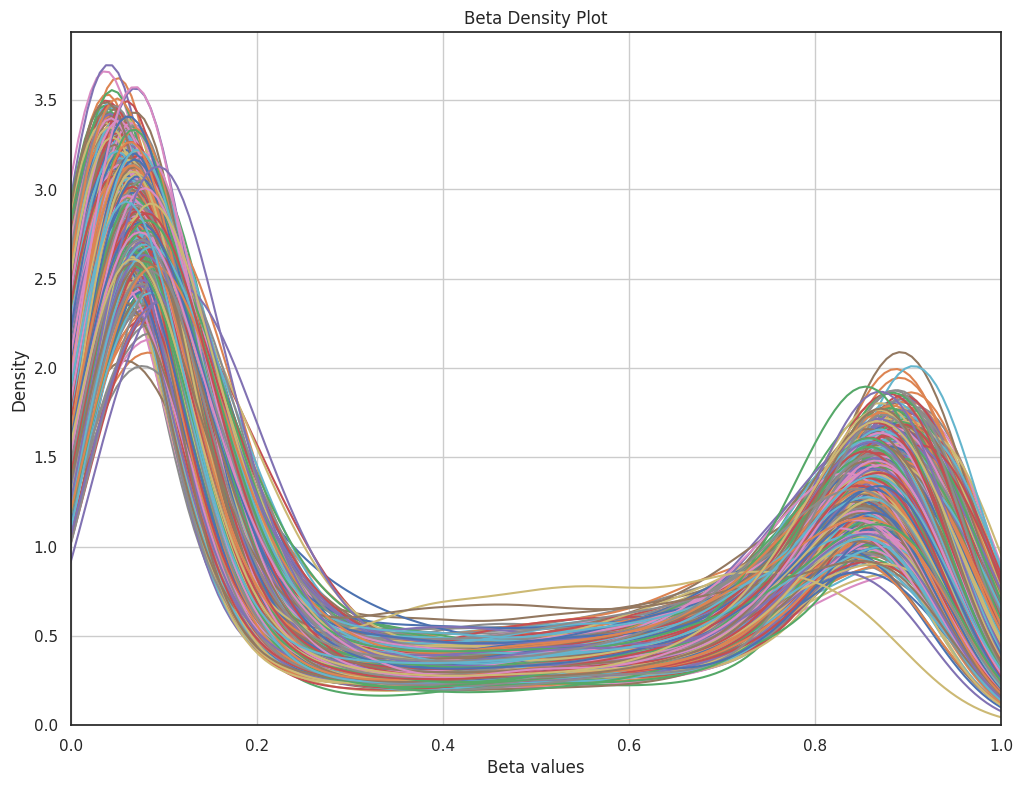

In [51]:
methylcheck.beta_density_plot(i450k_data)

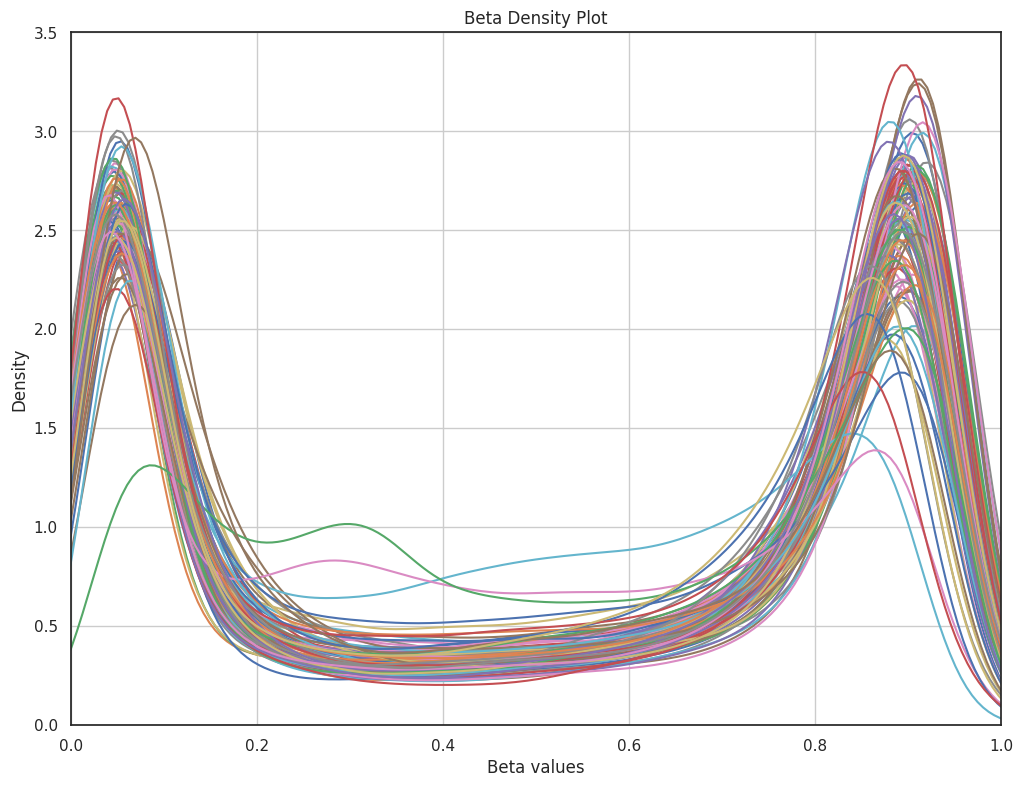

In [52]:
methylcheck.beta_density_plot(epic_data)

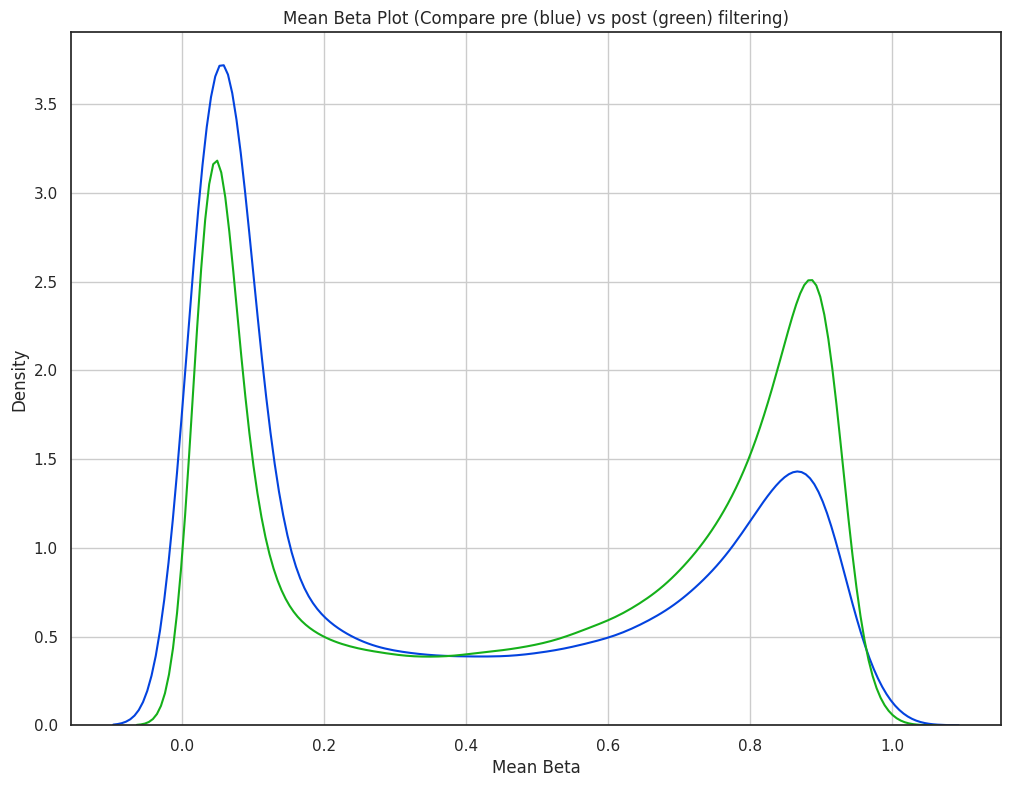

In [53]:
methylcheck.mean_beta_compare(i450k_data, epic_data)

In [26]:
# check if the final filtered dataset for both platforms include any missing values
print(f'The HM450K dataset includes: {i450k_data.isna().sum().sum()} missing values')
print(f'The EPIC dataset includes: {epic_data.isna().sum().sum()} missing values')

The HM450K dataset includes: 0 missing values
The EPIC dataset includes: 0 missing values


## Splitting the Datasets:

Now that I have two dataset for both the HM450K and EPIC filtered and cleaned, four new datasets will be formed:

- The 1370 form the HM450K platform samples will be divided to:

  - 1271 samples that are HM450 only and not common with EPIC, this set of smaples will be divided:

    - 80% training set, this is the first dataset.
    - 20% testing set, this will be the second dataset.  

  - 99 samples that are common with EPIC, this will be the third dataset and will be used as the first validation set.

- The 99 samples that were generted from the the RAW IDAT files are used as the forth dataset, and will act as a second validation set.

Stratify spliting was used in order to enusre that the proportions of each subtype or subgroup stays the same across sets, which can help the model deal with samples with rare subtypes. Another question is why should we include two validation set that include the same smaples and the same probs isn't this just redundancy. No not really, since the EPIC validation set is generate from RAW IDAT files it might include slightly different beta values from the 99 samples in the HM450. this might be beneficial to see if the model can handle noise in data.

In [27]:
# get the target or subtypes for the HM450 platform
i450k_target = i450K_meta_with_subtype['subtype']
# make a full dataframe that include the smaples, feature, and targets
i450k_full_data = pd.concat([i450k_data, i450k_target], axis=1)
i450k_full_data

,cg00001583,cg00002719,cg00003202,cg00003287,cg00007898,cg00009292,cg00011717,cg00031456,cg00035237,cg00035249,...,cg27519579,cg27523491,cg27532722,cg27545494,cg27585287,cg27611781,cg27656573,cg27657537,cg27662611,subtype
GSM3876338,0.020419,0.000045,0.006677,0.864179,0.000032,0.085469,0.775973,0.004984,0.014963,0.009010,...,0.774723,0.049306,0.128368,0.014678,0.054298,0.092385,0.866739,0.434325,0.066337,8
GSM3876339,0.000028,0.009592,0.005699,0.145974,0.000048,0.074632,0.875221,0.022494,0.018683,0.008870,...,0.540764,0.046496,0.308684,0.033835,0.057182,0.088182,0.850016,0.169859,0.090877,2
GSM3876340,0.028478,0.000041,0.006331,0.580937,0.000031,0.059165,0.934045,0.003985,0.009462,0.011222,...,0.629701,0.035808,0.545858,0.046036,0.078179,0.162596,0.904304,0.633877,0.055283,4
GSM3876341,0.021277,0.025809,0.000015,0.655122,0.003516,0.110040,0.897591,0.005005,0.008802,0.002174,...,0.765634,0.051643,0.391984,0.028717,0.075586,0.066422,0.883825,0.526852,0.050239,2
GSM3876342,0.004986,0.000074,0.000328,0.417514,0.004890,0.062697,0.929853,0.001475,0.007431,0.004605,...,0.653505,0.018505,0.582948,0.030514,0.058264,0.091315,0.865492,0.477546,0.043323,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.043014,0.010787,0.020752,0.814910,0.059299,0.160996,0.823775,0.045490,0.042840,0.043147,...,0.783156,0.055173,0.391232,0.037950,0.169338,0.082366,0.919105,0.712177,0.121184,6
GSM3877853,0.033505,0.010339,0.015487,0.749059,0.041219,0.110446,0.830988,0.035438,0.033924,0.030201,...,0.745209,0.067544,0.285195,0.025254,0.098726,0.062886,0.880191,0.381176,0.134100,8
GSM3877854,0.064631,0.007381,0.046807,0.663204,0.082894,0.101805,0.646937,0.027398,0.047892,0.027556,...,0.618421,0.096091,0.731084,0.042694,0.118702,0.091641,0.903320,0.691233,0.071894,7
GSM3877855,0.074294,0.060296,0.078243,0.903840,0.045381,0.217468,0.862174,0.044310,0.079782,0.027878,...,0.784838,0.061551,0.386007,0.034317,0.137963,0.103669,0.920153,0.755478,0.201523,7


In [28]:
# get the target or subtypes for the EPIC platforms
epic_target = meta_with_subtype['subtype']
# a full dataframe to include the samples, features, and target
epic_full_data = pd.concat([epic_data, epic_target], axis=1)
epic_full_data

,cg00000029,cg00000109,cg00000165,cg00000221,cg00000236,cg00000289,cg00000363,cg00000540,cg00000622,cg00000658,...,cg27665829,cg27665860,cg27665925,cg27665978,cg27665985,cg27666046,cg27666049,cg27666108,cg27666123,subtype
GSM3877742,0.464983,0.853972,0.781386,0.773450,0.882367,0.731638,0.088491,0.600224,0.056532,0.791970,...,0.793609,0.166400,0.042723,0.468330,0.144758,0.230410,0.635743,0.139380,0.871577,4
GSM3877746,0.391612,0.855882,0.866048,0.905968,0.893847,0.785334,0.059543,0.733451,0.024663,0.827541,...,0.884564,0.627800,0.021841,0.828489,0.130205,0.035308,0.802519,0.386554,0.811262,8
GSM3877747,0.602910,0.871100,0.612691,0.880840,0.883682,0.801787,0.047535,0.874093,0.028950,0.768196,...,0.911704,0.491986,0.021273,0.785357,0.098935,0.188259,0.830656,0.175548,0.895707,8
GSM3877748,0.192169,0.913039,0.655652,0.886648,0.902098,0.858521,0.058248,0.554826,0.026092,0.815153,...,0.919328,0.449932,0.021255,0.557841,0.254928,0.032289,0.793131,0.130233,0.703602,1
GSM3877749,0.626437,0.909628,0.883808,0.908054,0.883342,0.862855,0.076808,0.629075,0.021937,0.812313,...,0.930785,0.463170,0.018966,0.525512,0.155575,0.061247,0.932023,0.076698,0.912625,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.344480,0.807543,0.777852,0.853293,0.887083,0.758617,0.052799,0.794921,0.050682,0.780952,...,0.896802,0.585808,0.022945,0.554376,0.147313,0.059726,0.803494,0.169600,0.840502,8
GSM3877851,0.399101,0.872157,0.331468,0.711033,0.898206,0.725435,0.067274,0.591796,0.055489,0.741460,...,0.854986,0.188081,0.031538,0.783405,0.080132,0.050591,0.567425,0.217847,0.835609,3
GSM3877852,0.431995,0.866406,0.764881,0.884803,0.846919,0.809182,0.039273,0.841439,0.032281,0.762599,...,0.882868,0.362193,0.025582,0.653389,0.289446,0.049979,0.816297,0.314286,0.664571,6
GSM3877853,0.233082,0.810646,0.813939,0.883618,0.897325,0.770517,0.059056,0.909822,0.029718,0.789614,...,0.880507,0.688493,0.019994,0.670983,0.053874,0.091763,0.811244,0.100081,0.887983,8


In [29]:
# choose only smaples that are specific to the HM450 smaples and not common with the EPIC platform
hm450_only = i450k_full_data .loc[
    ~i450k_full_data .index.isin(epic_data.index),
    :
]

# choose the samples that are common with the EPIC platform , this is the first validation set
hm450_validation_set = i450k_full_data.loc[
    i450k_full_data .index.isin(epic_data.index),
    :
]

# the epic beta values that were generate from the RAW IDAT files will be the second validation set
epic_validation_set = epic_full_data

# spilt the set that only includes smaples for HM450 into a training and testing set, 80-20 split
X_hm450_training_set, X_hm450_testing_set, y_hm450_training_set, y_hm450_testing_set = train_test_split(
    hm450_only.drop('subtype', axis=1),
    hm450_only['subtype'],
    test_size=0.2,
    stratify=hm450_only['subtype'],
    random_state=42
)

print("HM450 Training set shape:", X_hm450_training_set.shape)
print("HM450 Testing set shape:", X_hm450_testing_set.shape)

print("\nTraining subtype distribution:")
print(y_hm450_training_set.value_counts(normalize=True))

print("\nTesting subtype distribution:")
print(y_hm450_testing_set.value_counts(normalize=True))

HM450 Training set shape: (1016, 129152)
HM450 Testing set shape: (255, 129152)

Training subtype distribution:
subtype
8    0.252953
7    0.220472
2    0.127953
4    0.103346
3    0.091535
6    0.091535
5    0.079724
1    0.032480
Name: proportion, dtype: float64

Testing subtype distribution:
subtype
8    0.254902
7    0.223529
2    0.129412
4    0.101961
6    0.090196
3    0.090196
5    0.078431
1    0.031373
Name: proportion, dtype: float64


## Extra Filtering:

To reduce the number of probs even more the standred diviation for each prob will be sorted in a descending order and then we choose the top 25k probs just as the second paper states [2]. Find highly correlated probs within the top 25k probs, which resulted in 11601 probs. All of this is done only on the training set, this is because if this was done on all datasets, data leakage might occur, but if each set has different number of probs, when using the model for testing or validation the model will through an error, so in order to avoid that a process of harmonization across sets needs to occur, meaning that the probs that are in the training set and also included in the other three sets will be choosen. The process of harmonization resulted in 9010 probs.

In [30]:
# get the standered diviation
std_values = X_hm450_training_set.std(axis=0)
# sorted in a descending order
std_sorted = std_values.sort_values(ascending=False)
# choose the top 25k probes
top_25k_features = std_sorted.head(25000).index
# select the top 25k probs
X_train_25k = X_hm450_training_set[top_25k_features]

print("Selected features:", len(top_25k_features))

Selected features: 25000


> **Consolidation note:** The original correlation filter treats numeric subtype labels as ordered values. The resulting 9,010-probe panel is preserved as a historical experiment. The later reusable pipeline uses variance selection fitted inside cross-validation instead.

In [31]:
# get the target for the top 25k probs
y_train_25k = y_hm450_training_set[X_train_25k.index]
# get the correlation for the top25k probs with the target
corr = X_train_25k.apply(lambda col: col.corr(y_train_25k))
# choose only the high correlated probs
selected_features = corr[abs(corr) >= 0.4].index

print("Selected features:", len(selected_features))

Selected features: 11601


In [32]:
# get all uniques probs from all sets with no redundancy
train_probes = set(selected_features) # the prob selection will depend on the selected features
test_probes = set(X_hm450_testing_set.columns)
hm450_val_probes = set(hm450_validation_set.columns)
epic_val_probes = set(epic_validation_set.columns)

# get the cmmon probs across all of them
common_probes = list(train_probes & test_probes & hm450_val_probes & epic_val_probes)

print("Number of common probes:", len(common_probes))

Number of common probes: 9010


In [33]:
# choose the common probs and print the dimensions for all sets to make sure that the result is correct
X_hm450_training_set = X_hm450_training_set[common_probes]
X_hm450_testing_set = X_hm450_testing_set[common_probes]
hm450_validation_set = hm450_validation_set[common_probes]
epic_validation_set = epic_validation_set[common_probes]
print(f'hm450 training set Dimensions: {X_hm450_training_set.shape}')
print(f'hm450 testing set Dimensions: {X_hm450_testing_set.shape}')
print(f'HM450 validation set Dimensions: {hm450_validation_set.shape}')
print(f'Epic validation set Dimensions: {epic_validation_set.shape}')

hm450 training set Dimensions: (1016, 9010)
hm450 testing set Dimensions: (255, 9010)
HM450 validation set Dimensions: (99, 9010)
Epic validation set Dimensions: (99, 9010)


In [39]:
# function to get the number of smaples for each subtypes
def summarize_dataset(name, X, y):
    # get the counts for all subtypes in the set
    counts = y.value_counts()

    # name of the set and the total number of smaples
    summary = {
        "Dataset": name,
        "Total Samples": X.shape[0]
    }

    # include the number of smaples for each subtype
    for subtype, count in counts.items():
        summary[subtype] = count

    return summary

In [40]:
# include a list of all summary for all sets
summary_list = [
    summarize_dataset("HM450 Train", X_hm450_training_set, y_hm450_training_set),
    summarize_dataset("HM450 Test", X_hm450_testing_set, y_hm450_testing_set),
    summarize_dataset("HM450 Validation", hm450_validation_set, meta_with_subtype['subtype']),
    summarize_dataset("EPIC Validation", epic_validation_set, meta_with_subtype['subtype'])
]

# fill not known with 0
summary_df = pd.DataFrame(summary_list).fillna(0)

# order of subtypes or subgroups
subtype_order = ["1", "2", "3", "4", "5", "6", "7", "8"]
final_columns = ["Dataset", "Total Samples"] + subtype_order

for col in subtype_order:
    if col not in summary_df.columns:
        summary_df[col] = 0

summary_df = summary_df[final_columns]

summary_df

,Dataset,Total Samples,1,2,3,4,5,6,7,8
0,HM450 Train,1016,33,130,93,105,81,93,224,257
1,HM450 Test,255,8,33,23,26,20,23,57,65
2,HM450 Validation,99,10,14,8,9,7,4,22,25
3,EPIC Validation,99,10,14,8,9,7,4,22,25


From the print statements and the table, it can be observed that the dimensions for all the sets are corret and the number of smaples for each subtype is laso correct according to the second research paper [2].

## Dimensionality Reduction:

After getting the filtered training set 9010 probs is still too high to do classification, so Dimensionality reduction is done using NMF, since the nature of the sets that include beta values are also between 0 and 1, so the sets inlcude positive values, becuase of that NMF can be used since it is most efficient with datasets with only non-negative numbers. After trying multiple number of `n_components` 10 was the most suitble one with the best results, this will produce a data set with only 10 features, which is way less that 9010 features. After dimensionality reduction use standred scaler to get a mean of 0 and standered diviation of 1 so we can do princple components analysis, 3 components will be choosen not based on thier explained variance but because I aim to visualize the clusters in 3D.

> **Consolidation note:** This exploratory NMF was fitted to the transposed matrix. The classification work in Part 2 uses the conventional samples-by-probes orientation. Metagene dominance is descriptive; it is not a percentage of biological contribution.

In [41]:
# make an NMF model with only 10 components
model = NMF(n_components=10, init='nndsvd', max_iter=100000, random_state=0)
# fit the data
W = model.fit_transform(X_hm450_training_set.T)
# get the coefficient matrix
H = model.components_
H.shape

(10, 1016)

In [42]:
# attach the nume of the smaples to the reduced dataframe
components_df = pd.DataFrame(H, columns=X_hm450_training_set.T.columns)
components_df = components_df.T
components_df

,0,1,2,3,4,5,6,7,8,9
GSM3877027,0.000000,0.113642,0.512583,0.000000,0.000000,0.091625,0.000000,0.000000,0.000000,2.962604
GSM3877144,0.020554,0.000000,0.002144,1.831359,0.524602,0.184205,0.713039,0.257650,0.000000,0.239988
GSM3877451,0.158879,0.274806,0.862273,0.000000,0.000000,0.118529,0.328554,0.392795,2.285936,0.408562
GSM3877389,0.000000,0.411946,1.252852,0.000000,0.230260,0.088893,0.183668,0.512260,0.000000,1.516605
GSM3877390,1.386838,0.192333,0.000000,0.190647,0.386630,0.355497,0.881518,0.347161,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
GSM3876500,0.698445,0.042102,0.000000,0.000000,0.674082,0.000000,0.389267,1.100646,1.403056,0.157316
GSM3877038,0.379132,0.007893,0.000000,1.579397,0.557849,0.050763,0.528701,0.143298,0.000000,0.054608
GSM3876856,0.542935,0.000000,0.000000,0.613535,1.473391,0.057497,1.379012,0.099544,0.000000,0.206500
GSM3876737,0.512931,0.000000,0.000000,0.617733,1.560671,0.149730,1.362535,0.043689,0.000000,0.000000


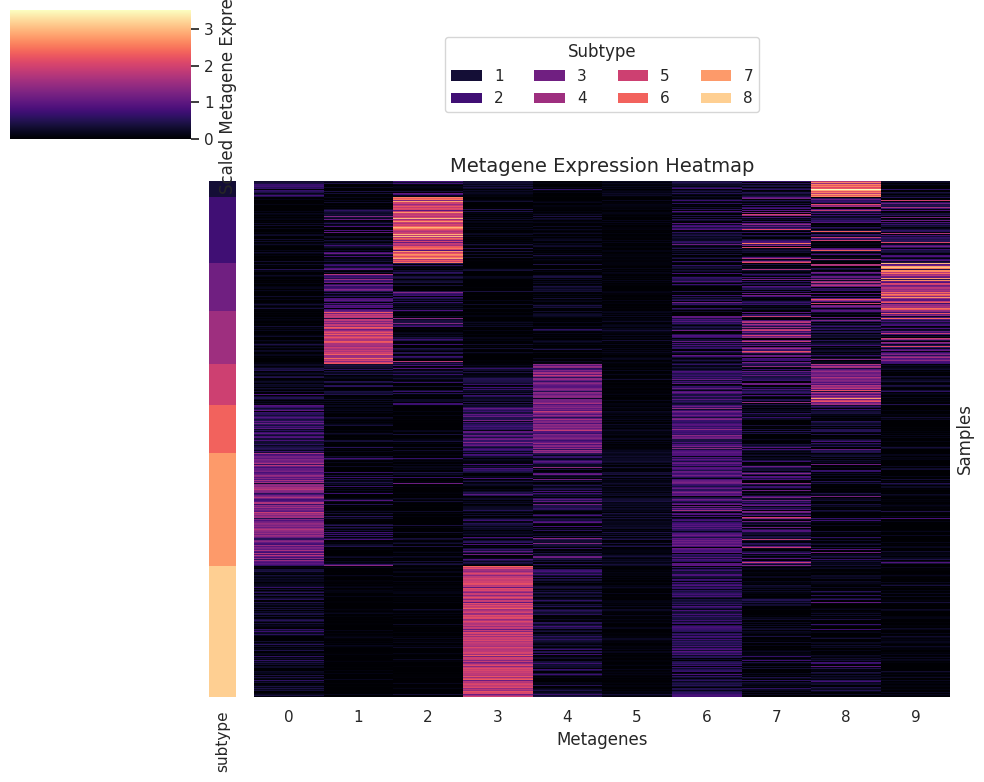

In [47]:
# set the theme for seaborn
sns.set_theme(style="white")

# combine & sort
heatmap = pd.concat((components_df, y_hm450_training_set), axis=1)
df_sorted = heatmap.sort_values("subtype")

subtype_sorted = df_sorted["subtype"]
df_sorted = df_sorted.drop(columns=["subtype"])

# create exactly 8 distinct colors derived from magma theme
import numpy as np
import matplotlib.pyplot as plt

unique_subtypes = sorted(subtype_sorted.unique())
cmap = plt.cm.magma
colors = [cmap(i) for i in np.linspace(0.1, 0.9, len(unique_subtypes))]
lut = dict(zip(unique_subtypes, colors))

row_colors = subtype_sorted.map(lut)

# Plot
g = sns.clustermap(
    df_sorted,
    cmap="magma",
    row_cluster=False,   # keep subtype order
    col_cluster=False,
    row_colors=row_colors,
    yticklabels=False,
    figsize=(10,8),
    cbar_kws={"label": "Scaled Metagene Expression"}
)

g.ax_heatmap.set_title("Metagene Expression Heatmap", fontsize=14)
g.ax_heatmap.set_xlabel("Metagenes")
g.ax_heatmap.set_ylabel("Samples")

# Add legend for subtype colors
for label in unique_subtypes:
    g.ax_col_dendrogram.bar(0, 0, color=lut[label], label=label, linewidth=0)

g.ax_col_dendrogram.legend(
    title="Subtype",
    loc="center",
    ncol=4
)

plt.tight_layout()
plt.show()

In [50]:
import numpy as np
import pandas as pd

# Assign dominant metagene
dominant_metagene = np.argmax(components_df.values, axis=1)

results = pd.DataFrame({
    "Subtype": y_hm450_training_set.values,
    "Dominant_Metagene": dominant_metagene
})

pd.crosstab(results["Subtype"], results["Dominant_Metagene"])

Dominant_Metagene,0,1,2,3,4,6,7,8,9
Subtype,,,,,,,,,
1,0,0,0,0,0,0,0,33,0
2,0,0,110,0,0,0,3,15,2
3,0,2,0,0,0,0,10,20,61
4,0,74,2,0,0,0,13,0,16
5,0,0,1,0,27,1,4,48,0
6,6,0,0,14,57,12,1,3,0
7,159,3,1,3,13,20,22,3,0
8,0,0,0,256,0,0,0,1,0


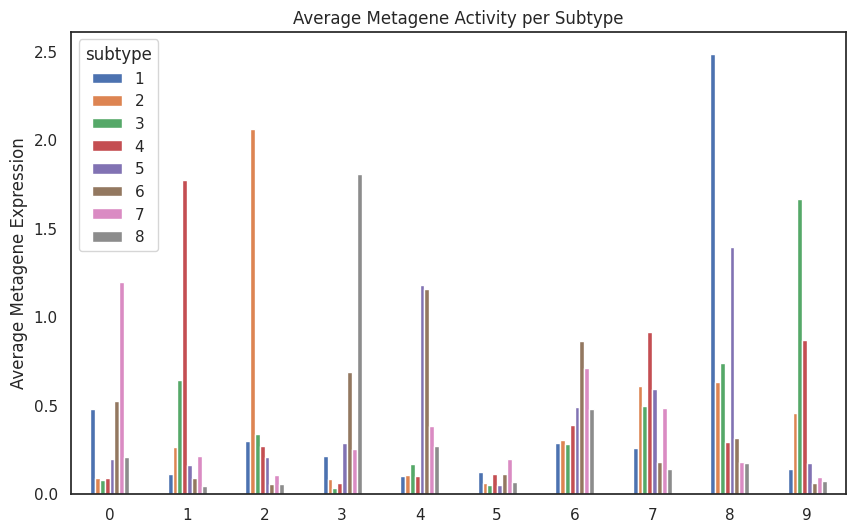

In [49]:
mean_expression = pd.concat(
    [components_df, y_hm450_training_set],
    axis=1
).groupby("subtype").mean()

mean_expression.T.plot(kind="bar", figsize=(10,6))
plt.ylabel("Average Metagene Expression")
plt.title("Average Metagene Activity per Subtype")
plt.xticks(rotation=0)
plt.show()

> **Consolidation note:** Metagene labels in the original table are zero-based. The dominant-count table assigns subtype 6 most often to column `4` (the fifth component); the prose below names the fourth metagene. The original text is retained so the correction is explicit.

## Metagenes Interpretations:

- The ninth metagene contributes to the first subtype by 100 %.

- Most of the contribution for the second subtype is from the 3rd metagene, representing by 110 out of 130 of samples, with smaller contributions from the 9th metagene.

- The third subtype is mainly driven by the 10th metagene with more than 50%.

- The fourth subtype is primarily associated with the 2st metagene, followed by smaller contributions from the 8th and 10th metagenes.

- The fifth subtype is largely influenced by the 9th metagene by more than 50%, with a good portion of samples being influnced by the 5th metagene.

- The sixth subtype shows its strongest signal from the 4th metagene.

- The seventh subtype is strongly dominated by the 1th metagene, although there is moderate spread across several other metagenes.

- The eighth subtype is almost entirely defined by the 4th metagene, showing extremely strong and clean separation.


Overall the plot and table shows clear contribution from metagenes to subtypes, which can indicate that NMF was very effective. However, they also show some overlap with subtypes like 3, 4, 5, and 6 subtype which is normal for methylation data.  

In [44]:
# create a scaler
scaler = StandardScaler()

# fit the data and make sure to set the columns and index
X_scaled = pd.DataFrame(
    scaler.fit_transform(components_df),
    index=components_df.index,
    columns=components_df.columns
)

X_scaled

,0,1,2,3,4,5,6,7,8,9
GSM3877027,-0.871847,-0.437404,0.171911,-0.842472,-0.889531,-0.106549,-1.504874,-0.848154,-0.752768,4.345119
GSM3877144,-0.829588,-0.639264,-0.556985,1.622469,0.292116,0.819349,0.591416,-0.343946,-0.752768,-0.207863
GSM3877451,-0.545192,-0.151129,0.671261,-0.842472,-0.889531,0.162525,-0.538946,-0.079475,2.805027,0.074039
GSM3877389,-0.871847,0.092470,1.229000,-0.842472,-0.370880,-0.133875,-0.964901,0.154312,-0.752768,1.927001
GSM3877390,1.979489,-0.297625,-0.560047,-0.585868,-0.018662,2.532461,1.086734,-0.168779,-0.752768,-0.609191
...,...,...,...,...,...,...,...,...,...,...
GSM3876500,0.564154,-0.564478,-0.560047,-0.842472,0.628812,-1.022899,-0.360454,1.305752,1.430926,-0.346115
GSM3877038,-0.092352,-0.625244,-0.560047,1.283338,0.367003,-0.515214,0.049473,-0.567726,-0.752768,-0.517871
GSM3876856,0.244427,-0.639264,-0.560047,-0.016676,2.429227,-0.447866,2.549335,-0.653352,-0.752768,-0.263864
GSM3876737,0.182738,-0.639264,-0.560047,-0.011027,2.625821,0.474563,2.500894,-0.762656,-0.752768,-0.609191


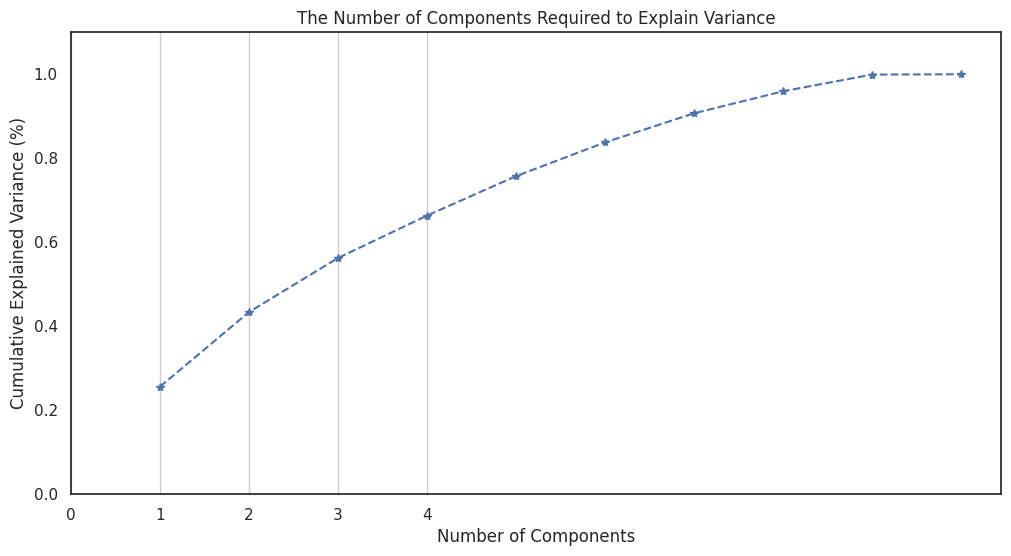

In [45]:
# this code is taken from the practicals
# plot the explained variance
pca = PCA().fit(X_scaled)

plt.rcParams["figure.figsize"] = (12,6)

fig, ax = plt.subplots()
xi = np.arange(1, 11, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='*', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 5, step=1)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('The Number of Components Required to Explain Variance')

#plt.axhline(y=1, color='b', linestyle='-')
#plt.text(0.5, 0.95, '100% cut-off threshold', color = 'blue', fontsize=12)

ax.grid(axis='x')
plt.show()

In [ ]:
# specify the number of components
Number_of_components_percentage = 3
pca = PCA(n_components=Number_of_components_percentage)

# clean up column names
# give column names to dataframe
columns = ['PC%i' % i for i in range(1, Number_of_components_percentage+1)]
score_pca = pca.fit_transform(X_scaled)
# create PCA dataframe
X_scaled_Display = pd.DataFrame(pca.fit_transform(X_scaled),columns=columns)
X_scaled_Display = X_scaled_Display.set_index(X_scaled.index)
X_scaled_Display

,PC1,PC2,PC3
GSM3877027,2.862035,0.871755,-1.241463
GSM3877144,-1.390255,0.903895,-0.751074
GSM3877451,1.554814,0.144417,2.075576
GSM3877389,2.245688,0.172276,-0.520982
GSM3877390,-2.067727,-2.438428,-0.703206
...,...,...,...
GSM3876500,0.197570,-0.485134,1.697141
GSM3877038,-1.308640,1.278209,-0.501489
GSM3876856,-2.550292,-0.516208,0.586631
GSM3876737,-2.901124,-0.885830,0.700720


In [ ]:
# add the target to the dataset with the three principle components
pca_dataframe = pd.concat((X_scaled_Display,y_hm450_training_set), axis = 1)
pca_dataframe

,PC1,PC2,PC3,subtype
GSM3877027,2.862035,0.871755,-1.241463,3
GSM3877144,-1.390255,0.903895,-0.751074,8
GSM3877451,1.554814,0.144417,2.075576,2
GSM3877389,2.245688,0.172276,-0.520982,3
GSM3877390,-2.067727,-2.438428,-0.703206,7
...,...,...,...,...
GSM3876500,0.197570,-0.485134,1.697141,5
GSM3877038,-1.308640,1.278209,-0.501489,8
GSM3876856,-2.550292,-0.516208,0.586631,6
GSM3876737,-2.901124,-0.885830,0.700720,6


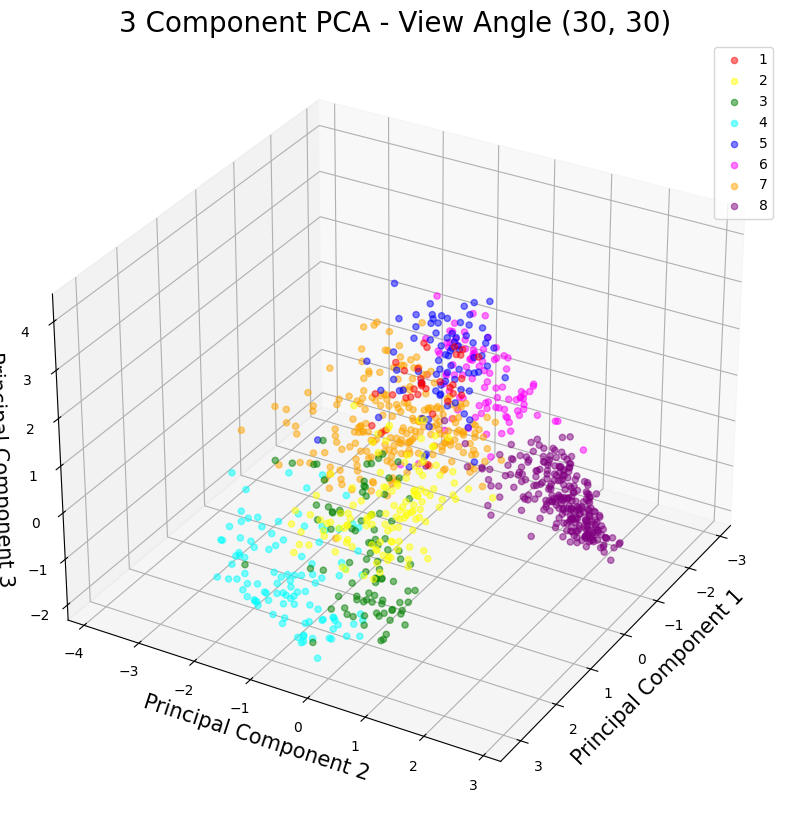

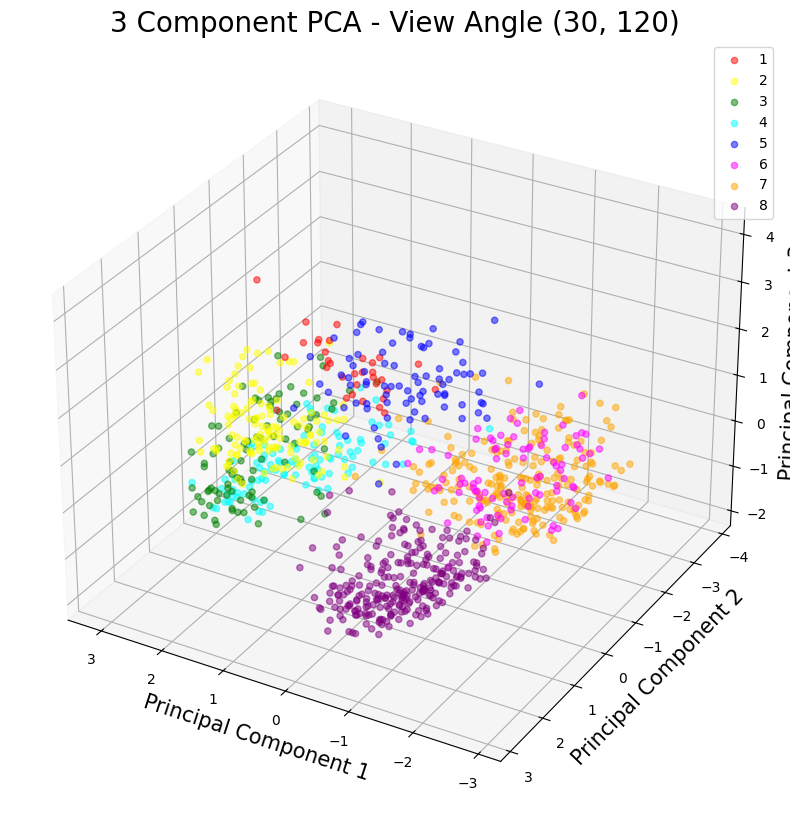

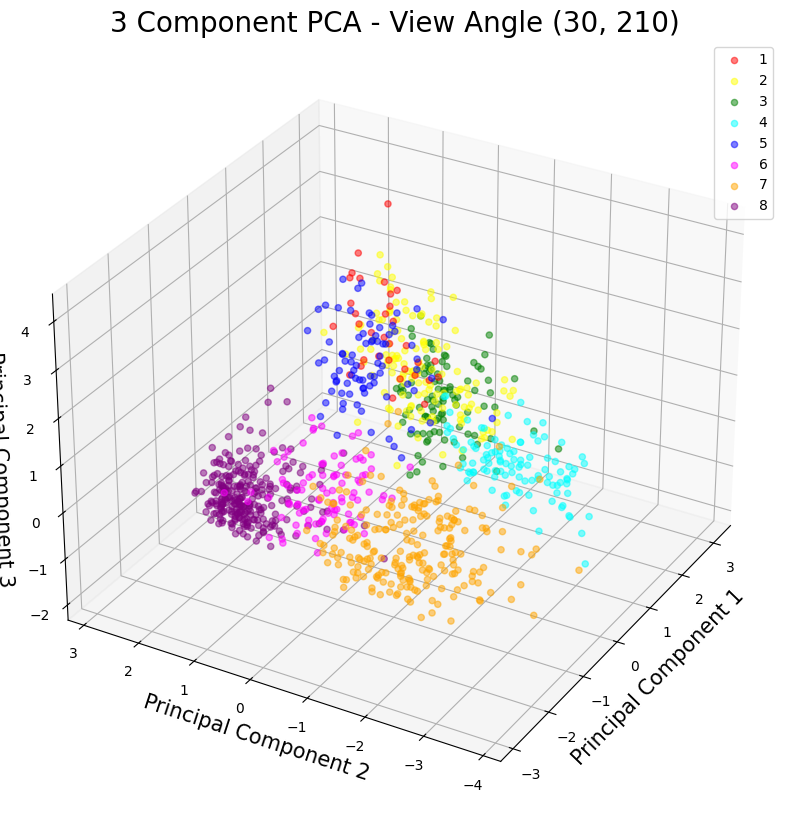

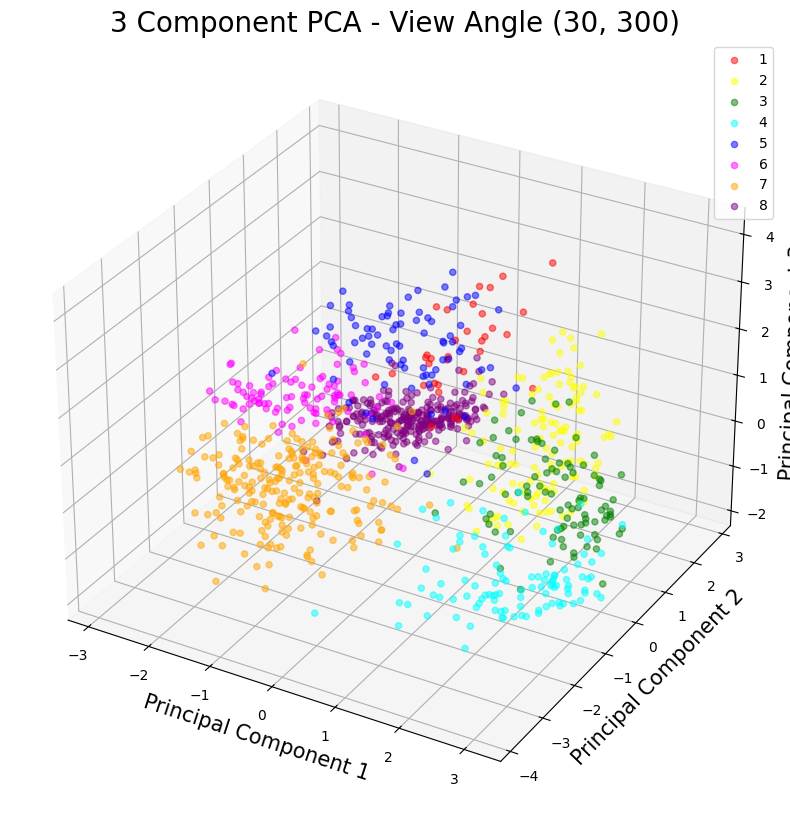

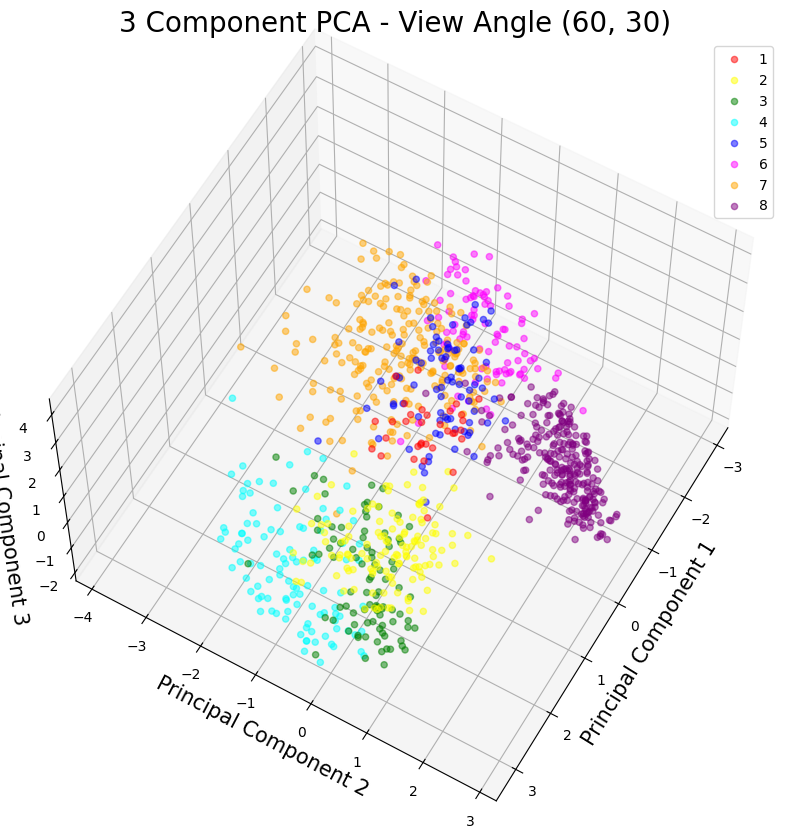

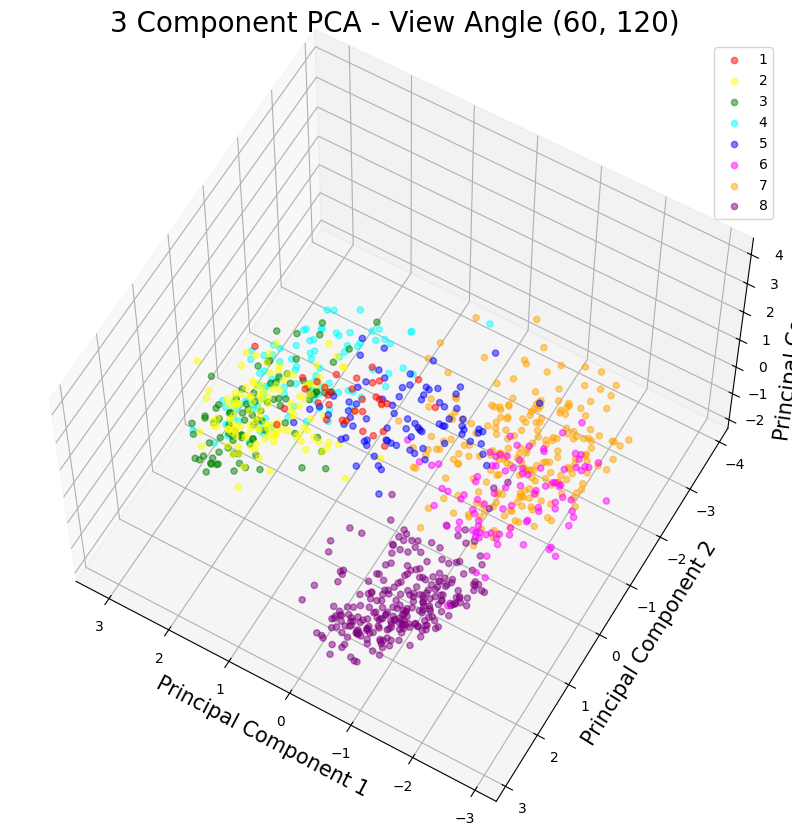

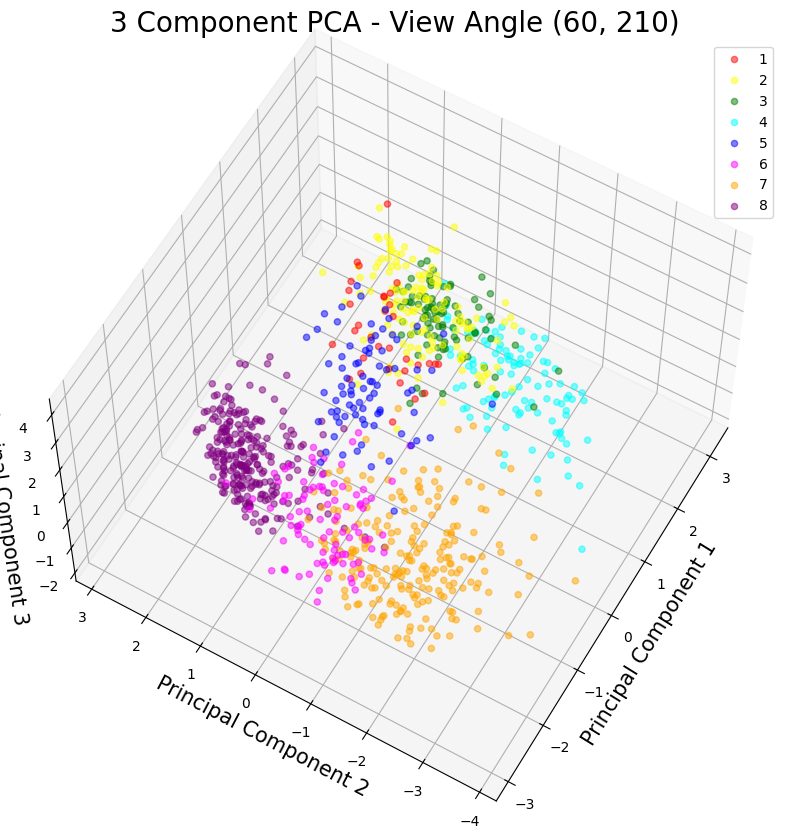

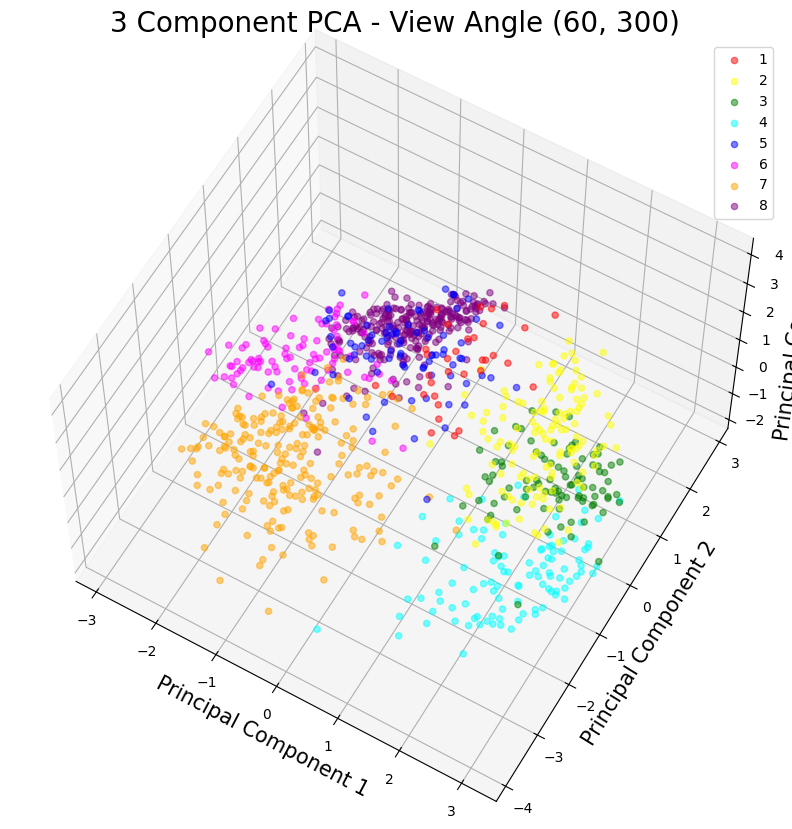

In [ ]:
# This code is taking from the practicals
angles = [(30, 30), (30, 120), (30, 210), (30, 300),
          (60, 30), (60, 120), (60, 210), (60, 300)]

# Loop through the defined angles to create plots
for elev, azim in angles:
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=elev, azim=azim)

    targets = ['1', '2', '3', '4', '5', '6', '7', '8']
    colors = [
    'red',
    'yellow',
    'green',
    'cyan',
    'blue',
    'magenta',
    'orange',
    'purple'
    ]

    for target, color in zip(targets, colors):
        indicesToKeep = pca_dataframe['subtype'] == target
        ax.scatter(pca_dataframe.loc[indicesToKeep, 'PC1'],
                   pca_dataframe.loc[indicesToKeep, 'PC2'],
                   pca_dataframe.loc[indicesToKeep, 'PC3'],
                   c=color,
                   s=20,
                   alpha=0.5)

    ax.set_xlabel('Principal Component 1', fontsize=15)
    ax.set_ylabel('Principal Component 2', fontsize=15)
    ax.set_zlabel('Principal Component 3', fontsize=15)
    ax.set_title(f'3 Component PCA - View Angle ({elev}, {azim})', fontsize=20)
    ax.legend(targets)
    ax.grid()
    plt.show()

## Clustring Interpretations:

From the 3d visualization resulted from using PCA, the 7th subtype is clearly sperated but spread, the fourth is also almost separated, while subtype 2 and 3 are interconnected and not separated from each other. The most clear sepsrated subtype is the 8th subtype and it is also not very spread, because looking back at the metagene table it can be observed that most of the contribution is coming from one metagene. Another question that raises if one metagene fully contributes to one subtype why is the first subtype not saperated from other cluster, this goes back to the fact that the number of samples that belong to the first subtype is small combared to other subtypes. 6 and 5 subtype are laso not very well seperated since they don't have one metagene that dominates.

## Dataset Generation:

In [60]:
# added the target to the corresponding dataset and include the reduced one also  then check dimensionality
hm450_train_df = pd.concat([X_hm450_training_set, y_hm450_training_set.rename("subtype")], axis=1)
reduced_hm450_train_df = pd.concat([components_df, y_hm450_training_set.rename("subtype")], axis=1)
hm450_test_df = pd.concat([X_hm450_testing_set, y_hm450_testing_set.rename("subtype")], axis=1)
hm450_val_df = pd.concat([hm450_validation_set, meta_with_subtype['subtype']], axis=1)
epic_val_df = pd.concat([epic_validation_set, meta_with_subtype['subtype']], axis=1)
print(f'hm450_train_df Dimensions: {hm450_train_df.shape}')
print(f'reduced_hm450_train_df Dimensions: {reduced_hm450_train_df.shape}')
print(f'hm450_test_df Dimensions: {hm450_test_df.shape}')
print(f'hm450_val_df Dimensions: {hm450_val_df.shape}')
print(f'epic_val_df Dimensions: {epic_val_df.shape}')

hm450_train_df Dimensions: (1016, 9011)
reduced_hm450_train_df Dimensions: (1016, 11)
hm450_test_df Dimensions: (255, 9011)
hm450_val_df Dimensions: (99, 9011)
epic_val_df Dimensions: (99, 9011)


In [61]:
hm450_train_df.to_csv("/content/drive/MyDrive/hm450_train_df.csv", index=False)
reduced_hm450_train_df.to_csv("/content/drive/MyDrive/reduced_hm450_train_df.csv", index=False)
hm450_test_df.to_csv("/content/drive/MyDrive/hm450_test_df.csv", index=False)
hm450_val_df.to_csv("/content/drive/MyDrive/hm450_val_df.csv", index=False)
epic_val_df.to_csv("/content/drive/MyDrive/epic_val_df.csv", index=False)

## Refrence:

[1] https://link.springer.com/article/10.1007/s00401-019-02020-0

[2] https://arxiv.org/pdf/2510.02416

[3] https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE130051

[4] https://zwdzwd.github.io/InfiniumAnnotation/?utm_source=chatgpt.com

[5] https://github.com/FoxoTech/methylcheck/blob/master/docs/filtering-probes.ipynb

# Part 2 — Classification, tuning and validation

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import NMF
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import squareform
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, log_loss, make_scorer, f1_score, accuracy_score
from sklearn.model_selection import learning_curve, validation_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import time

print(f'numpy {np.__version__}')
print(f'matplotlib {matplotlib.__version__}')
print(f'seaborn {sns.__version__}')
print(f'pandas {pd.__version__}')

google_colab_path = '/content/drive/My Drive/ai for health/data'
local_env_path = '../data' 

numpy 2.2.6
matplotlib 3.10.8
seaborn 0.13.2
pandas 2.3.3


In [2]:
#drive.mount('/content/drive')

## 1. Classification Model Development

> **Consolidation note:** The available prepared EPIC matrix contains 97 rows, as shown in the saved shapes below, rather than the 99 mentioned in this original paragraph. The 99-row HM450-compatible validation matrix and 97 EPIC rows represent overlapping specimen records, not independent patient cohorts or proof of two physical assays for each tumor.

### 1.1 Training and Test Set Preperation

To prepare the the data for classification the final HM450k final, epic final files, metadata, and common probs were read. 

- Train set `common_probs`, includes the 1016 smaples for the training data and 13.9k probs.
- `HM450k_final` includes 1370 smaples which will include also some epic samples.
- `epic_final` includes 99 samples that are for the epic platform.
- `metadata` includes information for the smaples like platform and subtypes and subgroups which will become important.

The first step is to load the metadata to extract `subgroups` and `subtypes` for each sample, then I needed to find the common probs that are in the `common_probs` file in the HM450k and epic daataset, this resulted in only finding 11.2k probs. The `hm450_final` dataset it includes the 1016 samples for the training and 255 for testing and 99 samples for the first validation set, while the `epic_final` dataset includes the 99 smaples for the second validation set. An info set was made for each dataset that includes both subgroups and subtypes for classification later.

#### Loading Files

In [3]:
# load the hm450k final samples 
df_hm450k = pd.read_parquet(f'{local_env_path}/hm450_final.parquet')
df_hm450k

,cg06833110,cg08782022,cg25900085,cg18924324,cg23928165,cg09794469,cg04021697,cg26825934,cg12528981,cg14606586,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3876338,0.585194,0.011008,0.952265,0.070308,0.005366,0.066601,0.275386,0.964099,0.003213,0.925236,...,0.765666,0.901646,0.000681,0.078268,0.368845,0.935924,0.924947,0.960384,0.585283,0.508766
GSM3876339,0.665192,0.909954,0.000065,0.990440,0.802644,0.966922,0.980155,0.000087,0.014086,0.005289,...,0.206654,0.311306,0.145043,0.598199,0.135943,0.108922,0.270451,0.395430,0.649667,0.121049
GSM3876340,0.963114,0.982010,0.009828,0.108785,0.929929,0.988755,0.951973,0.070918,0.966650,0.004424,...,0.623220,0.693172,0.659544,0.774480,0.622562,0.868721,0.917348,0.596964,0.390033,0.738974
GSM3876341,0.432923,0.879289,0.000043,0.904384,0.617361,0.979156,0.121285,0.011801,0.996582,0.010468,...,0.461277,0.361354,0.304467,0.748930,0.803449,0.925916,0.486513,0.766076,0.693428,0.348660
GSM3876342,0.537229,0.871607,0.000050,0.993634,0.598881,0.847534,0.800626,0.003304,0.895189,0.631810,...,0.888255,0.248915,0.846423,0.641511,0.176867,0.642114,0.621439,0.723099,0.676104,0.601927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.606724,0.103484,0.925041,0.863483,0.058963,0.108705,0.040272,0.776979,0.198909,0.746179,...,0.912917,0.916313,0.189580,0.355407,0.804935,0.945458,0.590575,0.757201,0.584732,0.552774
GSM3877853,0.556855,0.055812,0.816719,0.017160,0.016829,0.114453,0.068071,0.851228,0.309515,0.621121,...,0.870412,0.843917,0.205629,0.330730,0.786886,0.940742,0.509974,0.145831,0.600746,0.450897
GSM3877854,0.951653,0.300885,0.484136,0.397636,0.344391,0.854636,0.305975,0.059298,0.971110,0.017394,...,0.751598,0.713955,0.202901,0.140326,0.775681,0.914529,0.720427,0.129702,0.362040,0.182436


In [4]:
# load the epic smaples 
df_epic = pd.read_parquet(f'{local_env_path}/epic_final.parquet')
df_epic

,cg06833110,cg08782022,cg25900085,cg18924324,cg23928165,cg09794469,cg04021697,cg26825934,cg12528981,cg14606586,...,cg27206295,cg12732715,cg25832747,cg08909592,cg10699852,cg21831612,cg08039854,cg02152968,cg20300343,cg08380477
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.929131,0.880765,0.792795,0.859588,0.883948,0.897430,0.225301,0.139964,0.933569,0.071314,...,0.365285,0.655597,0.091525,0.396778,0.584927,0.554176,0.683633,0.701563,0.401683,0.271771
GSM3877746,0.960283,0.445126,0.918020,0.925255,0.550669,0.505484,0.046755,0.947862,0.632784,0.767979,...,0.848229,0.896746,0.607623,0.459325,0.624650,0.934708,0.746521,0.314761,0.746116,0.435994
GSM3877747,0.056151,0.082874,0.877274,0.092775,0.200870,0.056032,0.277040,0.823319,0.493752,0.532992,...,0.859130,0.722793,0.171472,0.320480,0.779779,0.954344,0.743552,0.545718,0.623693,0.237438
GSM3877748,0.972257,0.887655,0.315499,0.951547,0.903141,0.924024,0.487866,0.518681,0.848756,0.213297,...,0.687409,0.543785,0.076941,0.375633,0.703861,0.656104,0.429989,0.476763,0.528854,0.512916
GSM3877749,0.168119,0.096290,0.729617,0.076039,0.498030,0.348018,0.112516,0.224159,0.964203,0.048914,...,0.866651,0.709357,0.180203,0.180749,0.646629,0.946192,0.788168,0.486913,0.276860,0.327383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.776426,0.111109,0.892450,0.107266,0.071427,0.069965,0.086436,0.915145,0.134739,0.863409,...,0.880383,0.878292,0.145133,0.270071,0.734527,0.931015,0.554970,0.080428,0.793558,0.179217
GSM3877851,0.109494,0.911012,0.152785,0.128882,0.909418,0.893705,0.074218,0.111732,0.199838,0.073087,...,0.434507,0.325950,0.175204,0.313546,0.139802,0.259813,0.533127,0.117860,0.009805,0.262951
GSM3877852,0.627091,0.073112,0.930719,0.911365,0.049413,0.066521,0.061052,0.879851,0.119674,0.771281,...,0.912917,0.916313,0.189580,0.355407,0.804935,0.945458,0.590575,0.757201,0.584732,0.552774


In [5]:
#load metadata information
df_meta_data = pd.read_csv(f'{local_env_path}/gse130051_metadata.csv')
df_meta_data

,Unnamed: 0,gsm,title,platform,cohort,tissue,subgroup,subtype
0,0,GSM3876338,6026818126_R01C01,GPL13534,GSE93646,Medulloblastoma,MB_G4,8
1,1,GSM3876339,6026818126_R04C01,GPL13534,GSE93646,Medulloblastoma,MB_G3,2
2,2,GSM3876340,6026818136_R01C02,GPL13534,GSE93646,Medulloblastoma,MB_G3,4
3,3,GSM3876341,6164655140_R01C01,GPL13534,GSE93646,Medulloblastoma,MB_G3,2
4,4,GSM3876342,6164655140_R03C01,GPL13534,GSE93646,Medulloblastoma,MB_G3,2
...,...,...,...,...,...,...,...,...
1496,1496,GSM3877852,200876170073_R07C01,GPL21145,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,6
1497,1497,GSM3877853,200882160027_R04C01,GPL21145,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,8
1498,1498,GSM3877854,200925700136_R04C01,GPL21145,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G3,7
1499,1499,GSM3877855,9444374158_R02C01,GPL13534,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,7


In [6]:
train_set = pd.read_csv(f'{local_env_path}/Train_Set1_MB_CommonProbes.csv')
train_set = train_set.set_index('Samples')
train_set

,cg00001269,cg00005740,cg00007076,cg00007466,cg00008564,cg00012692,cg00014104,cg00014830,cg00016238,cg00016481,...,cg27655168,cg27655507,cg27655671,cg27657363,cg27657439,cg27659557,cg27662246,cg27663123,cg27664085,Group
Samples,,,,,,,,,,,,,,,,,,,,,
GSM3876338,0.792820,0.804463,0.582601,0.870547,0.470907,0.840971,0.723692,0.100159,0.520965,0.044182,...,0.686155,0.594742,0.582653,0.134002,0.925824,0.815907,0.096983,0.297289,0.982909,8
GSM3876339,0.216427,0.887788,0.041595,0.733992,0.603031,0.095884,0.061645,0.374587,0.660019,0.805971,...,0.138300,0.332662,0.790548,0.795202,0.206654,0.326788,0.673529,0.713417,0.012994,2
GSM3876340,0.396410,0.709442,0.545285,0.853530,0.835008,0.861878,0.819503,0.902422,0.928984,0.949298,...,0.475675,0.611751,0.752460,0.675785,0.324070,0.340166,0.886550,0.766391,0.637476,4
GSM3876342,0.346532,0.807284,0.110365,0.833279,0.766298,0.620862,0.097100,0.214434,0.960432,0.849197,...,0.377016,0.335575,0.730118,0.794087,0.726036,0.610346,0.756215,0.310152,0.136801,2
GSM3876343,0.771003,0.966399,0.732097,0.840162,0.651781,0.769284,0.445487,0.154520,0.229538,0.039613,...,0.604753,0.755801,0.525151,0.293551,0.923527,0.590674,0.151554,0.274030,0.931935,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877739,0.126082,0.199820,0.321151,0.889835,0.819811,0.663315,0.435930,0.835789,0.879097,0.930642,...,0.383103,0.102417,0.914081,0.519225,0.360077,0.125001,0.866212,0.573953,0.000098,3
GSM3877740,0.535087,0.884332,0.688289,0.862230,0.792824,0.855403,0.574916,0.539652,0.858752,0.187535,...,0.818155,0.745030,0.764990,0.486046,0.588993,0.842023,0.792784,0.762268,0.906342,7
GSM3877741,0.290677,0.439811,0.454326,0.806088,0.684356,0.147234,0.164753,0.755453,0.970251,0.933618,...,0.185983,0.424749,0.894470,0.647291,0.432698,0.232902,0.836046,0.486208,0.067688,3


#### Getting subgroups and subtypes for both platforms

In [7]:
# set the platform names 
HM450K_PLATFORM = 'GPL13534'
EPIC_PLATFORM = 'GPL21145'

# extract the smaples for each platform
hm450_meta = df_meta_data[
    (df_meta_data['platform'] == HM450K_PLATFORM) &
    (df_meta_data['subtype'] != 'MBNOS')
].copy()

epic_meta = df_meta_data[
    (df_meta_data['platform'] == EPIC_PLATFORM) &
    (df_meta_data['subtype'] != 'MBNOS')
].copy()

# chech the number of smaples for each platform
print(f"Cleaned HM450k samples: {len(hm450_meta)}")
print(f"Cleaned EPIC samples: {len(epic_meta)}")

Cleaned HM450k samples: 1271
Cleaned EPIC samples: 99


In [8]:
# get the ids or gsm for the hm450 samples 
hm450k_ids = set(df_hm450k.index)
meta_ids = set(df_meta_data['gsm'])
# extract them fromt he final hm450k
common_samples_hm450 = list(hm450k_ids.intersection(meta_ids))

# get the hm450 subgroups and subtypes
df_meta_common = df_meta_data[df_meta_data['gsm'].isin(common_samples_hm450)].set_index('gsm')
df_HM450k_common = df_hm450k.loc[list(common_samples_hm450)]
df_subtypes_hm450k = df_meta_common.loc[df_HM450k_common.index, ['subgroup', 'subtype']]

df_subtypes_hm450k

,subgroup,subtype
gsm,,
GSM3877005,MB_G3,4
GSM3877844,MB_G4,5
GSM3877285,MB_G3,7
GSM3877264,MB_G3,4
GSM3877704,MB_G4,7
...,...,...
GSM3877336,MB_G4,7
GSM3876804,MB_G4,7
GSM3877584,MB_G4,7


In [9]:
# get the ids or gsm for the epic smaples 
epic_ids = set(df_epic.index)
# extract the epic samples 
common_samples_epic = list(epic_ids.intersection(meta_ids))

# get the epic subtypes and subgroups
df_meta_common = df_meta_data[df_meta_data['gsm'].isin(common_samples_epic)].set_index('gsm')
df_epic_common = df_epic.loc[list(common_samples_epic)]
df_subtypes_epic = df_meta_common.loc[df_epic_common.index, ['subgroup', 'subtype']]


df_subtypes_epic

,subgroup,subtype
gsm,,
GSM3877752,MB_G4,8
GSM3877819,MB_G4,6
GSM3877844,MB_G4,5
GSM3877758,MB_G3,4
GSM3877853,MB_G4,8
...,...,...
GSM3877825,MB_G4,7
GSM3877796,MB_G4,8
GSM3877774,MB_G4,8


#### Common Probs and Creating Final sets

In [10]:
# find the common probs between the training set and the hm450k 
common_probes = train_set.columns.intersection(df_hm450k.columns)
print(f"Number of common probes: {len(common_probes)}")

Number of common probes: 11234


In [11]:
# get the training set with the common probs
train_set = train_set[common_probes]
train_set_info = df_subtypes_hm450k.loc[train_set.index]
train_set

,cg00001269,cg00005740,cg00007076,cg00008564,cg00012692,cg00014104,cg00014830,cg00016238,cg00016481,cg00017842,...,cg27648224,cg27652490,cg27655168,cg27655507,cg27655671,cg27657363,cg27657439,cg27659557,cg27662246,cg27664085
Samples,,,,,,,,,,,,,,,,,,,,,
GSM3876338,0.792820,0.804463,0.582601,0.470907,0.840971,0.723692,0.100159,0.520965,0.044182,0.890100,...,0.345743,0.676384,0.686155,0.594742,0.582653,0.134002,0.925824,0.815907,0.096983,0.982909
GSM3876339,0.216427,0.887788,0.041595,0.603031,0.095884,0.061645,0.374587,0.660019,0.805971,0.215485,...,0.621060,0.721599,0.138300,0.332662,0.790548,0.795202,0.206654,0.326788,0.673529,0.012994
GSM3876340,0.396410,0.709442,0.545285,0.835008,0.861878,0.819503,0.902422,0.928984,0.949298,0.108245,...,0.836495,0.872049,0.475675,0.611751,0.752460,0.675785,0.324070,0.340166,0.886550,0.637476
GSM3876342,0.346532,0.807284,0.110365,0.766298,0.620862,0.097100,0.214434,0.960432,0.849197,0.502918,...,0.881425,0.698544,0.377016,0.335575,0.730118,0.794087,0.726036,0.610346,0.756215,0.136801
GSM3876343,0.771003,0.966399,0.732097,0.651781,0.769284,0.445487,0.154520,0.229538,0.039613,0.912372,...,0.346337,0.568335,0.604753,0.755801,0.525151,0.293551,0.923527,0.590674,0.151554,0.931935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877739,0.126082,0.199820,0.321151,0.819811,0.663315,0.435930,0.835789,0.879097,0.930642,0.606990,...,0.749234,0.884372,0.383103,0.102417,0.914081,0.519225,0.360077,0.125001,0.866212,0.000098
GSM3877740,0.535087,0.884332,0.688289,0.792824,0.855403,0.574916,0.539652,0.858752,0.187535,0.850895,...,0.541043,0.736437,0.818155,0.745030,0.764990,0.486046,0.588993,0.842023,0.792784,0.906342
GSM3877741,0.290677,0.439811,0.454326,0.684356,0.147234,0.164753,0.755453,0.970251,0.933618,0.186555,...,0.606875,0.789602,0.185983,0.424749,0.894470,0.647291,0.432698,0.232902,0.836046,0.067688


In [12]:
# get all samples for the hm450 platform 
temp_set = df_hm450k[common_probes]
temp_set

,cg00001269,cg00005740,cg00007076,cg00008564,cg00012692,cg00014104,cg00014830,cg00016238,cg00016481,cg00017842,...,cg27648224,cg27652490,cg27655168,cg27655507,cg27655671,cg27657363,cg27657439,cg27659557,cg27662246,cg27664085
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3876338,0.792820,0.804463,0.582601,0.470907,0.840971,0.723692,0.100159,0.520965,0.044182,0.890100,...,0.345743,0.676385,0.686155,0.594742,0.582653,0.134002,0.925824,0.815907,0.096983,0.982909
GSM3876339,0.216427,0.887788,0.041595,0.603031,0.095884,0.061645,0.374587,0.660019,0.805971,0.215485,...,0.621060,0.721599,0.138300,0.332662,0.790548,0.795202,0.206654,0.326788,0.673529,0.012994
GSM3876340,0.396410,0.709442,0.545285,0.835008,0.861878,0.819503,0.902422,0.928984,0.949298,0.108245,...,0.836495,0.872049,0.475675,0.611751,0.752460,0.675785,0.324070,0.340166,0.886550,0.637476
GSM3876341,0.774766,0.976479,0.185296,0.655047,0.466416,0.213114,0.492804,0.974171,0.972100,0.387051,...,0.772104,0.727548,0.213422,0.194476,0.854081,0.865417,0.813347,0.423233,0.877605,0.125249
GSM3876342,0.346532,0.807284,0.110365,0.766298,0.620862,0.097100,0.214434,0.960432,0.849197,0.502918,...,0.881425,0.698544,0.377016,0.335575,0.730118,0.794087,0.726036,0.610346,0.756215,0.136801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877852,0.819121,0.913531,0.881668,0.666981,0.821102,0.836868,0.265640,0.978025,0.219876,0.892689,...,0.379989,0.735138,0.812171,0.899534,0.480193,0.528781,0.906770,0.849154,0.429804,0.958185
GSM3877853,0.811805,0.903087,0.807631,0.180626,0.786182,0.577889,0.184157,0.171508,0.288448,0.852036,...,0.257656,0.327817,0.722174,0.778941,0.304304,0.408714,0.901323,0.870822,0.273785,0.304186
GSM3877854,0.518422,0.739723,0.724289,0.479104,0.744645,0.277551,0.232453,0.968695,0.470364,0.769304,...,0.622917,0.556248,0.665848,0.697838,0.734739,0.447514,0.691363,0.624440,0.772830,0.731072


In [13]:
# exclude both the training hm450 smaples and the 99 samples that overlaps with epic 
epic_ids = epic_meta['gsm'].tolist()
train_ids = train_set.index.tolist()
exclude_ids = set(epic_ids + train_ids)

In [14]:
# the dataset without the training and validation hm450 is the testing set 
test_set = temp_set[~temp_set.index.isin(exclude_ids)]
test_set_info = df_subtypes_hm450k.loc[test_set.index]
test_set

,cg00001269,cg00005740,cg00007076,cg00008564,cg00012692,cg00014104,cg00014830,cg00016238,cg00016481,cg00017842,...,cg27648224,cg27652490,cg27655168,cg27655507,cg27655671,cg27657363,cg27657439,cg27659557,cg27662246,cg27664085
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3876341,0.774766,0.976479,0.185296,0.655047,0.466416,0.213114,0.492804,0.974171,0.972100,0.387051,...,0.772104,0.727548,0.213422,0.194476,0.854081,0.865417,0.813347,0.423233,0.877605,0.125249
GSM3876345,0.823717,0.978797,0.758399,0.050632,0.762038,0.891304,0.081964,0.181720,0.038351,0.873150,...,0.048441,0.077561,0.746911,0.836504,0.357695,0.413528,0.900476,0.688999,0.102353,0.721998
GSM3876352,0.818642,0.941673,0.787490,0.312491,0.681227,0.551253,0.110893,0.295183,0.159267,0.827882,...,0.161504,0.269402,0.778958,0.838462,0.166089,0.195294,0.782752,0.835157,0.234540,0.920555
GSM3876353,0.688151,0.954993,0.103105,0.162863,0.778769,0.547595,0.538515,0.464012,0.852213,0.856061,...,0.356415,0.551318,0.182761,0.417738,0.304710,0.788008,0.282093,0.342154,0.263147,0.665955
GSM3876366,0.335536,0.702214,0.667559,0.844704,0.356600,0.224245,0.922090,0.907107,0.819734,0.753849,...,0.744505,0.904717,0.409023,0.143703,0.915371,0.582030,0.857658,0.209935,0.846042,0.974198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877721,0.582201,0.781850,0.552794,0.823989,0.750275,0.119274,0.873413,0.917220,0.763941,0.747773,...,0.777064,0.856249,0.466799,0.400366,0.888790,0.710359,0.195674,0.353399,0.864490,0.950553
GSM3877726,0.856774,0.910527,0.824033,0.162047,0.859647,0.881800,0.130055,0.177885,0.126452,0.872008,...,0.183366,0.194814,0.684928,0.864594,0.216493,0.527336,0.853031,0.853637,0.181753,0.863107
GSM3877732,0.294580,0.729442,0.346428,0.712309,0.601338,0.214359,0.643073,0.937860,0.850842,0.366081,...,0.654457,0.771800,0.529976,0.404901,0.838866,0.660273,0.306610,0.435558,0.837070,0.126920


In [15]:
# the 99 samples that overlap with the epic platform and extraced from the hm450
hm450_validation_set = temp_set[temp_set.index.isin(epic_ids)]
hm450_validation_set_info = df_subtypes_hm450k.loc[hm450_validation_set.index]
hm450_validation_set

,cg00001269,cg00005740,cg00007076,cg00008564,cg00012692,cg00014104,cg00014830,cg00016238,cg00016481,cg00017842,...,cg27648224,cg27652490,cg27655168,cg27655507,cg27655671,cg27657363,cg27657439,cg27659557,cg27662246,cg27664085
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.383810,0.741290,0.819239,0.781392,0.550149,0.771093,0.150684,0.973320,0.958523,0.862883,...,0.807975,0.900581,0.133457,0.671508,0.732430,0.648544,0.779479,0.320131,0.856792,0.842148
GSM3877746,0.729423,0.909370,0.847480,0.343762,0.815815,0.832794,0.833897,0.058603,0.683880,0.720635,...,0.228885,0.525521,0.763935,0.744664,0.830113,0.741950,0.923858,0.717389,0.133212,0.973000
GSM3877747,0.760578,0.841962,0.767337,0.322817,0.736325,0.691672,0.312811,0.412829,0.112078,0.870142,...,0.355616,0.198431,0.749054,0.900035,0.568063,0.116276,0.903673,0.849975,0.116183,0.978762
GSM3877748,0.572329,0.919967,0.605061,0.542786,0.385237,0.212437,0.452258,0.958978,0.764841,0.897695,...,0.512405,0.842166,0.521976,0.591216,0.743985,0.644070,0.555588,0.133046,0.532341,0.962145
GSM3877749,0.790268,0.828233,0.764084,0.514298,0.776015,0.475552,0.505012,0.986332,0.328771,0.847336,...,0.488927,0.806214,0.728854,0.768160,0.673452,0.471460,0.829468,0.544558,0.662188,0.918483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.843189,0.774130,0.854649,0.122222,0.751821,0.860519,0.160651,0.061385,0.118283,0.863242,...,0.139863,0.138683,0.521808,0.847514,0.255823,0.434879,0.930778,0.866084,0.194383,0.905870
GSM3877851,0.158093,0.525500,0.107839,0.815007,0.158729,0.106001,0.283155,0.952449,0.943614,0.113106,...,0.658929,0.773731,0.113104,0.140011,0.858651,0.600487,0.500571,0.182666,0.624798,0.065654
GSM3877852,0.819121,0.913531,0.881668,0.666981,0.821102,0.836868,0.265640,0.978025,0.219876,0.892689,...,0.379989,0.735138,0.812171,0.899534,0.480193,0.528781,0.906770,0.849154,0.429804,0.958185


In [16]:
# the 97 samples from the epic platform 
epic_validation_set = df_epic[common_probes]
epic_validation_set_info = df_subtypes_hm450k.loc[epic_validation_set.index]
epic_validation_set

,cg00001269,cg00005740,cg00007076,cg00008564,cg00012692,cg00014104,cg00014830,cg00016238,cg00016481,cg00017842,...,cg27648224,cg27652490,cg27655168,cg27655507,cg27655671,cg27657363,cg27657439,cg27659557,cg27662246,cg27664085
gsm,,,,,,,,,,,,,,,,,,,,,
GSM3877742,0.405005,0.823053,0.904424,0.894804,0.589178,0.886044,0.174259,0.901642,0.938227,0.934135,...,0.915514,0.959786,0.146497,0.678126,0.867369,0.769178,0.763168,0.350977,0.933797,0.834127
GSM3877746,0.798072,0.907359,0.935687,0.365491,0.833400,0.916054,0.920685,0.054265,0.679167,0.798672,...,0.237687,0.566818,0.844708,0.777437,0.920218,0.816396,0.926489,0.788085,0.140533,0.947769
GSM3877747,0.865627,0.868646,0.892412,0.389206,0.752299,0.772495,0.342822,0.410368,0.076909,0.945317,...,0.372254,0.219689,0.851079,0.889620,0.690202,0.134382,0.890433,0.938471,0.134285,0.941335
GSM3877748,0.598269,0.910071,0.679822,0.594806,0.387291,0.224300,0.528512,0.923754,0.773103,0.959069,...,0.540143,0.929063,0.554845,0.618667,0.861826,0.695024,0.558266,0.145730,0.559367,0.947707
GSM3877749,0.879898,0.859391,0.883615,0.565340,0.794670,0.491211,0.569585,0.951156,0.332204,0.932587,...,0.519296,0.896392,0.798124,0.782567,0.779666,0.482997,0.835361,0.568823,0.716296,0.937279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.930093,0.805388,0.930318,0.181777,0.796867,0.941274,0.210224,0.067321,0.084868,0.939911,...,0.159060,0.168416,0.543685,0.809000,0.367214,0.471091,0.916512,0.944035,0.244109,0.901251
GSM3877851,0.165994,0.465373,0.156815,0.900662,0.104901,0.105628,0.309759,0.926288,0.949954,0.115601,...,0.683837,0.870657,0.121239,0.178115,0.921310,0.653040,0.497599,0.200024,0.689346,0.187778
GSM3877852,0.895181,0.927038,0.947433,0.756302,0.851061,0.908115,0.272097,0.951258,0.181974,0.952239,...,0.364891,0.789683,0.882786,0.899227,0.569471,0.524199,0.908727,0.924420,0.416122,0.946815


#### All sets with shapes for checking

In [17]:
# check the shape for all datasets
print(f'Train set shape: {train_set.shape}')
print(f'Test set shape: {test_set.shape}')
print(f'HM450k Validation set shape: {hm450_validation_set.shape}')
print(f'EPIC Validation set shape: {epic_validation_set.shape}')

Train set shape: (1016, 11234)
Test set shape: (255, 11234)
HM450k Validation set shape: (99, 11234)
EPIC Validation set shape: (97, 11234)


In [18]:
# check the shape for all target datasets
print(f'Training information set shape: {train_set_info.shape}')
print(f'Testing information set shape: {test_set_info.shape}')
print(f'HM450k Validation information set shape: {hm450_validation_set_info.shape}')
print(f'EPIC Validation information set shape: {epic_validation_set_info.shape}')

Training information set shape: (1016, 2)
Testing information set shape: (255, 2)
HM450k Validation information set shape: (99, 2)
EPIC Validation information set shape: (97, 2)


#### NMF

In [ ]:
def compute_consensus_cophenetic(data, k, n_runs=30):
    n_samples = data.shape[0]
    
    # Initialize consensus matrix (tracks how often pairs cluster together)
    consensus = np.zeros((n_samples, n_samples), dtype=np.float32)

    # Repeat NMF multiple times with different random states
    for i in tqdm(range(n_runs)):
        # Fit NMF model with k components (clusters)
        model = NMF(n_components=k, init='random', random_state=i, max_iter=4000)
        W = model.fit_transform(data)
        
        # Assign each sample to the cluster with highest weight
        clusters = np.argmax(W, axis=1)

        # Create connectivity matrix:
        connectivity = (clusters[:, None] == clusters).astype(np.float32)
        consensus += connectivity

    # Average over all runs
    consensus /= n_runs
    distance_matrix = 1.0 - consensus

    # Ensure diagonal is zero 
    np.fill_diagonal(distance_matrix, 0)
    condensed_dist = squareform(distance_matrix)

    # Perform hierarchical clustering (average linkage)
    Z = linkage(condensed_dist, method='average')
    c, _ = cophenet(Z, condensed_dist)
    
    return c

> **Consolidation note:** This original plot has a recorded output, but its source references `ks` and `scores`, which are not defined in the submitted notebook. It is retained as part of the research record and is not presented as a successfully reproduced consensus experiment.

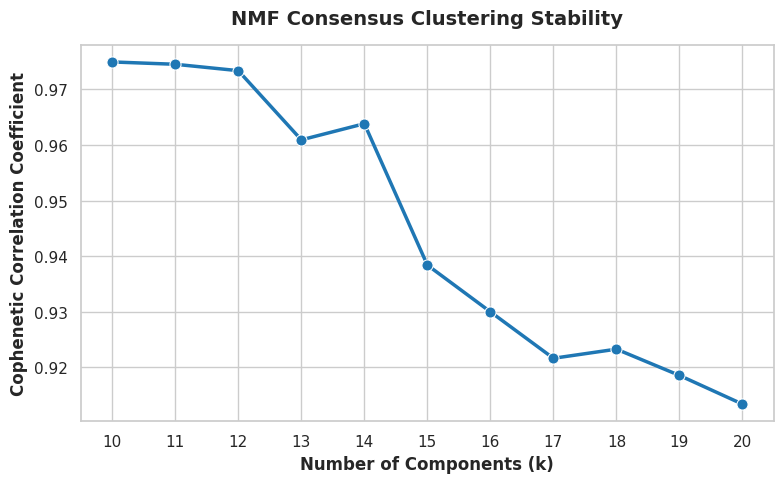

In [ ]:
df_plot = pd.DataFrame({
    'Rank (k)': ks,
    'Cophenetic Correlation': scores
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.lineplot(
    data=df_plot,
    x='Rank (k)',
    y='Cophenetic Correlation',
    marker='o',       
    markersize=8,     
    linewidth=2.5,    
    color='#1f77b4'   
)

plt.title('NMF Consensus Clustering Stability', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Components (k)', fontsize=12, fontweight='bold')
plt.ylabel('Cophenetic Correlation Coefficient', fontsize=12, fontweight='bold')
plt.xticks(ks)
plt.tight_layout()
plt.show()

In [19]:
# get the training x values
X = train_set.values

# init nmf object with only 10 components and max iter of 2000
nmf_model = NMF(n_components=10, init='nndsvd', random_state=42,  max_iter=2000)
new_dataset_matrix = nmf_model.fit_transform(X)

# get the new reduced dataset
new_dataset = pd.DataFrame(
    new_dataset_matrix, 
    index=train_set.index, 
    columns=['Metagene_1', 'Metagene_2', 'Metagene_3', 'Metagene_4', 'Metagene_5', 'Metagene_6', 'Metagene_7',
            'Metagene_8', 'Metagene_9', 'Metagene_10']
)

In [20]:
new_dataset

,Metagene_1,Metagene_2,Metagene_3,Metagene_4,Metagene_5,Metagene_6,Metagene_7,Metagene_8,Metagene_9,Metagene_10
Samples,,,,,,,,,,
GSM3876338,0.259919,0.000000,0.737082,0.000000,0.112115,0.435773,0.173280,0.134597,0.012573,0.140844
GSM3876339,0.000000,0.146253,0.000000,0.000000,0.209892,0.000000,0.000000,0.500731,1.756872,0.000000
GSM3876340,0.104820,0.900014,0.007499,2.115165,0.067551,0.062464,0.079578,0.199758,0.376102,0.350307
GSM3876342,0.252876,0.015602,0.023954,0.512043,0.029641,0.000000,0.224995,0.535640,1.770681,0.044442
GSM3876343,0.514075,0.000000,0.663364,0.000000,0.042310,0.468927,0.197996,0.142496,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
GSM3877739,0.151497,1.561581,0.000000,0.539666,0.000000,0.000000,0.000000,0.167652,0.705540,0.000000
GSM3877740,0.674054,0.074556,0.154162,0.819946,0.099532,0.701550,0.016765,0.303461,0.329520,1.547448
GSM3877741,0.126203,1.399544,0.019971,0.742786,0.381060,0.007320,0.114284,0.345223,0.111021,0.000000


In [21]:
# transform the testing set 
X_test = test_set.values.astype('float64')
test_dataset_matrix = nmf_model.transform(X_test)

# get the new reduced testing set 
new_test_dataset = pd.DataFrame(
    test_dataset_matrix, 
    index=test_set.index, 
    columns=['Metagene_1', 'Metagene_2', 'Metagene_3', 'Metagene_4', 'Metagene_5', 
             'Metagene_6', 'Metagene_7', 'Metagene_8', 'Metagene_9', 'Metagene_10']
)
new_test_dataset

,Metagene_1,Metagene_2,Metagene_3,Metagene_4,Metagene_5,Metagene_6,Metagene_7,Metagene_8,Metagene_9,Metagene_10
gsm,,,,,,,,,,
GSM3876341,0.195445,0.000000,0.002135,0.164497,0.000000,0.267236,0.000000,0.786132,1.717113,0.341880
GSM3876345,0.198490,0.000000,0.977064,0.000000,0.151906,0.011278,0.000000,0.178122,0.000000,0.000000
GSM3876352,0.381430,0.143148,0.926597,0.136666,0.000000,0.224339,0.000000,0.000000,0.005792,0.049093
GSM3876353,0.000000,0.000000,0.415929,0.116246,0.603071,0.000000,0.013701,0.000000,1.811269,0.647353
GSM3876366,0.000000,0.823921,0.000000,1.877467,0.216653,0.000000,0.212554,0.458248,0.081023,1.236080
...,...,...,...,...,...,...,...,...,...,...
GSM3877721,0.292983,0.530711,0.026424,2.198857,0.432394,0.205229,0.000000,0.353267,0.116356,0.375209
GSM3877726,0.231329,0.113356,1.009959,0.036654,0.191937,0.000000,0.000000,0.124621,0.192337,0.191291
GSM3877732,0.308074,0.613186,0.037325,1.226330,0.165421,0.113848,0.053756,0.153548,0.955558,0.000000


#### Analysis

Checking the distribution for all subtypes it can be observed that some subtypes have low number of samples, which might effect the model performance and result in the model biasing towards some subtypes.

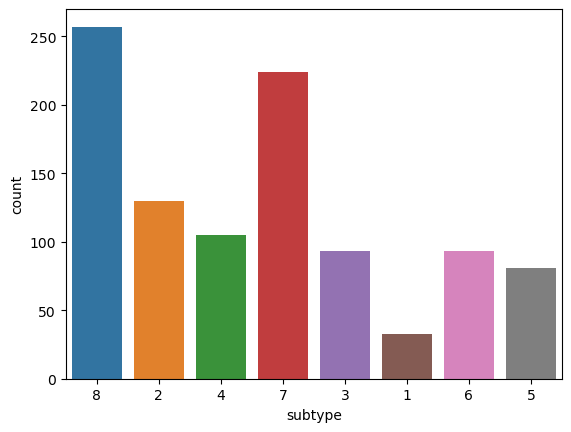

In [22]:
sns.countplot(data=train_set_info, x="subtype", hue='subtype')
plt.show()

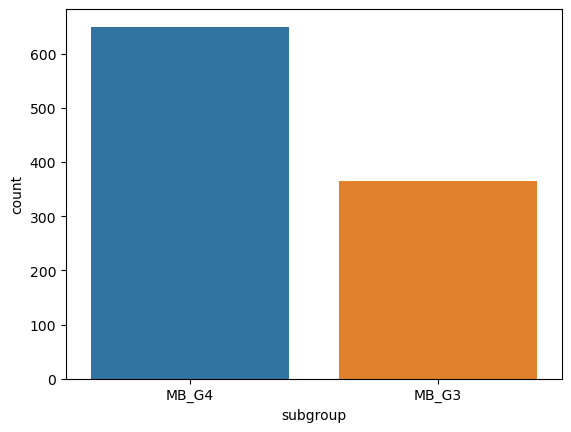

In [23]:
sns.countplot(data=train_set_info, x="subgroup", hue='subgroup')
plt.show()

### 1.2 Model Selection

Support Vector Machines was chosen for train and testing and specifically it's variant SVC, which is made for classification for:

- High dimnesionality: SVM is known to its ability to handle highly dimensional datasets, just like the dataset we are working with, this model was even used before in many other literatures for classifying medulloblastoma from methylation purposes [1].

- Handling Non-Linear Biological Complexity: when doing machine learning for biologoy purposes, it is know that the data will be complex, and when trying to classify smaples the difference between subgroups or subtyps might be very complex and subtle [2], so SVM can untangle complex, non-linear relationships in the training dataset

- Robustness to Class Imbalance: SVMs allow for easy integration of class weights, which directly penalizes misclassifications of minority classes.

### 1.3 Training

For the SVC initial hyperparameters:

- Kernal: Radial Basis Function or RBF was selected since it can efficiently handle non-linear data by using higher-dimensional feature space.
- class_weight='balanced': Analysis revealed a significant class imbalance among the eight molecular subtypes. this should help the model perform better at classification.
- C=1.0 (Regularization Parameter): since the nature of the data is high dimensional and complex, the model might suffer from overfitting, so a regularization is needed, 1.0 is a good starting point.
- gamma='scale': this helps the kernel claculating its width dynamically based on the number of features and the variance of the data, so the model doesn't overfit or undderfit.

A random state was set for reproducability.

In [24]:
# get a SVC model with init prarmeters 
svm_model = SVC(
    kernel='rbf', 
    C=1.0, 
    gamma='scale', 
    class_weight='balanced', 
    random_state=42, 
    probability=True
)

In [25]:
X_train = new_dataset
y_train = train_set_info['subtype']
X_test = new_test_dataset
y_test = test_set_info['subtype']
# train the model
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [26]:
# run the test using the testing set
y_pred = svm_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

> **Consolidation note:** This figure uses predictions on the 255-sample test set. The original assessment used the title “Cross-Validated Confusion Matrix” and zero-based axis positions. Its title and subtype labels have been corrected below; the original confusion counts are unchanged.

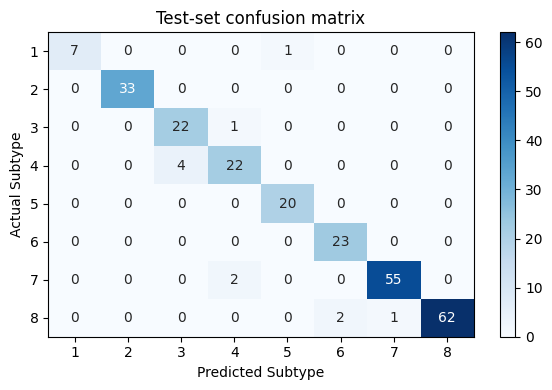

In [27]:
# Show the original test-set counts with their actual subtype labels.
fig, ax = plt.subplots(figsize=(6, 4))
subtype_labels = np.unique(y_test)
image = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.grid(False)
for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):
        color = 'white' if cm[row, column] > cm.max() / 2 else '#262626'
        ax.text(column, row, str(cm[row, column]), ha='center', va='center', color=color)
ax.set_xticks(np.arange(len(subtype_labels)), labels=subtype_labels)
ax.set_yticks(np.arange(len(subtype_labels)), labels=subtype_labels)
ax.set_title('Test-set confusion matrix')
ax.set_xlabel('Predicted Subtype')
ax.set_ylabel('Actual Subtype')
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

In [28]:
report = classification_report(y_test, y_pred)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           1       1.00      0.88      0.93         8
           2       1.00      1.00      1.00        33
           3       0.85      0.96      0.90        23
           4       0.88      0.85      0.86        26
           5       0.95      1.00      0.98        20
           6       0.92      1.00      0.96        23
           7       0.98      0.96      0.97        57
           8       1.00      0.95      0.98        65

    accuracy                           0.96       255
   macro avg       0.95      0.95      0.95       255
weighted avg       0.96      0.96      0.96       255



In [29]:
macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')
print(f"\nExplicit F1-Scores:")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Micro F1-Score: {micro_f1:.4f}")


Explicit F1-Scores:
Macro F1-Score: 0.9472
Micro F1-Score: 0.9569


The initial SVM model trained on the NMF-extracted metagenes achieved a high accuracy of 96%. However, evaluating the individual class metrics reveals specific subtype misclassifications driven by the dataset's class imbalance. Based on the confusion matrix and classification matrix:

- Subtype 4 subgroup 3: This subtype has the lowest perfoment model, the model missclassified 4 smaples, it classified those 4 smaples as subtype 3.

- Because the model classificed 4 smaples from subtype 4 as subtype 3 the precession for this subtype is low 0.85 compared to it's recall which is 0.96.

- For subtype 1 the model suffers from the effect of the data being unbalanced, since subtype 1 has very low number of smaples in the training set, because of this low number of smaples the model wasn't able to learn how to distinguish it, this is backed up by a recall 0f 0.88, which means the model missclassified one samples out of 8 from the testing set.

In [30]:
def analyze_decision_margins(model, X_test, y_test, margin_threshold=0.20):
    # Generate predictions and probabilities internally
    y_pred = model.predict(X_test)
    prob_matrix = model.predict_proba(X_test)
    model_classes = model.classes_

    # Top 2 probabilities and classes
    top2_indices = np.argsort(prob_matrix, axis=1)[:, -2:]
    top1_idx = top2_indices[:, 1]  
    top2_idx = top2_indices[:, 0]  
    
    top1_probs = prob_matrix[np.arange(len(prob_matrix)), top1_idx]
    top2_probs = prob_matrix[np.arange(len(prob_matrix)), top2_idx]
    
    top1_classes = model_classes[top1_idx]
    top2_classes = model_classes[top2_idx]

    # Results DataFrame
    results_df = pd.DataFrame({
        'Actual_Class': y_test,
        'Hard_Prediction': y_pred,           
        'Prob_Top1_Class': top1_classes,
        'Confidence_Top1': top1_probs.round(3),
        'Prob_RunnerUp_Class': top2_classes,
        'Confidence_Top2': top2_probs.round(3),
        'Decision_Margin': (top1_probs - top2_probs).round(3)
    }, index=y_test.index) # Keeps original sample names intact!

    # misclassifications and discordance
    misclassified_df = results_df[results_df['Actual_Class'] != results_df['Hard_Prediction']]
    discordant_df = misclassified_df[misclassified_df['Decision_Margin'] < margin_threshold]

    # Print summary
    print(f"--- Margin Analysis Summary ---")
    print(f"Total Misclassified Samples: {len(misclassified_df)}")
    print(f"Highly Discordant Misclassifications (Margin < {margin_threshold}): {len(discordant_df)}")
    print(f"Overall Model Log-Loss: {log_loss(y_test, prob_matrix):.4f}\n")

    return results_df, misclassified_df, discordant_df

In [31]:
# get details for misclassifications for the baseline model
full_results, misclassified, discordant = analyze_decision_margins(
    model=svm_model, 
    X_test=new_test_dataset, 
    y_test=y_test, 
    margin_threshold=0.20  
)

discordant

--- Margin Analysis Summary ---
Total Misclassified Samples: 11
Highly Discordant Misclassifications (Margin < 0.2): 3
Overall Model Log-Loss: 0.1323



,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3876607,1,5,5,0.413,2,0.238,0.175
GSM3876618,8,7,7,0.470,8,0.328,0.142
GSM3876997,8,6,8,0.432,6,0.379,0.053


In [32]:
misclassified

,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3876375,3,4,4,0.591,3,0.206,0.385
GSM3876396,8,6,8,0.616,6,0.363,0.253
GSM3876538,4,3,3,0.708,4,0.254,0.454
GSM3876607,1,5,5,0.413,2,0.238,0.175
GSM3876618,8,7,7,0.470,8,0.328,0.142
GSM3876851,7,4,4,0.931,7,0.038,0.894
GSM3876997,8,6,8,0.432,6,0.379,0.053
GSM3877008,4,3,3,0.717,4,0.246,0.470
GSM3877232,4,3,3,0.609,4,0.173,0.437


> **Consolidation note:** The quantity called a decision margin here is a top-two probability gap. A confident prediction that disagrees with a reference label does not establish that the label is wrong or that a tumor has mutated. These are hypotheses requiring additional evidence.

The model misclassifed 11 samples which was pointed out in the confussion matrix, but by using the predict probability function for the SVM model, insights and details about thos misclassifications can be derieved:

- The model finds it hard to distenguish between subtype 4 and 3, and between subtype 4 adn 7. The issue is that the probability for the predicted class is high reaching 60% and excedding it at times for many missclassified samples.

- Another observation can be noticed: the second highest probability is the correct class, but the probability gap is extremely high for samples GSM3876851 and GSM3877288. These confident errors are worth investigating:
      
    - The reference subtype assignments come from the research dataset. A confident model prediction does not show that the reference label is wrong; checking the sample and its original assignment would require additional evidence.
    - Sample quality or unusual methylation patterns are other possibilities to investigate, rather than conclusions that can be drawn from the prediction probability.
      

- Sometimes the model gives a high confidence score (Probability) for two subtypes, and the margin between them is very small, this is called a discordant smaples is a datapoint where the class gives a conflict class assignment, or confidence score that isn't dominate. Those scores can be linked to the model unable to generalize well, or not being able to distinuish between classes.

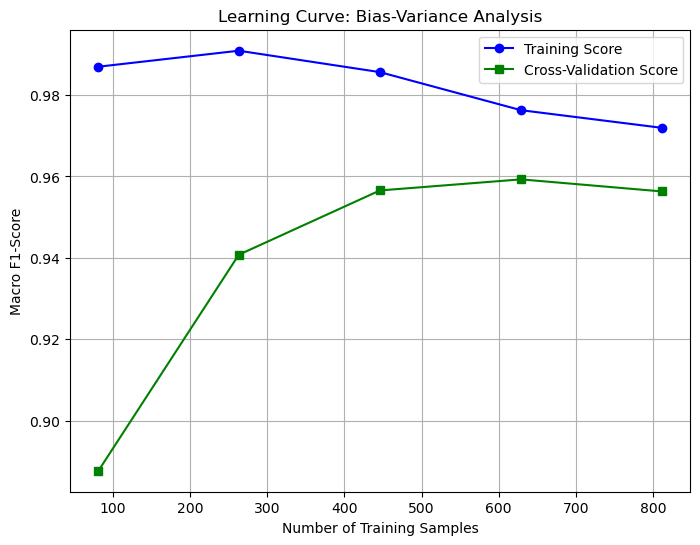

In [33]:
train_sizes, train_scores, test_scores = learning_curve(
    svm_model, new_dataset, y_train, cv=5, scoring='f1_macro', 
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue', marker='o')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='green', marker='s')
plt.title('Learning Curve: Bias-Variance Analysis')
plt.xlabel('Number of Training Samples')
plt.ylabel('Macro F1-Score')
plt.legend(loc='best')
plt.grid()
plt.show()

The learning curve shows a very stable model fit; at the beginning, with less training samples, the difference between the training and cross-validation scores is larger, but the validation score increases to ~0.96 and the training score decreases to ~0.97 when the number of training samples reaches 800, showing that increasing data reduced the model variance (overfitting). In addition, the high final F1-scores for both sets also show that the model does not have high bias (underfitting). The NMF metagene features offer a complex enough feature space for the SVM to establish generalizable decision boundaries.

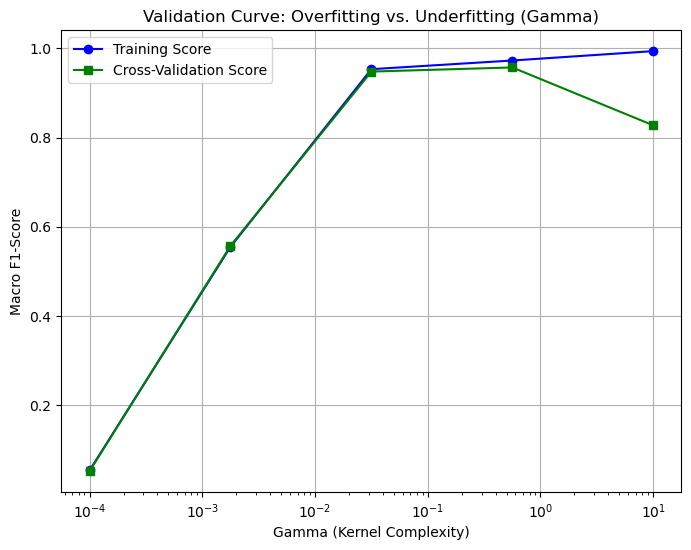

In [34]:
param_range = np.logspace(-4, 1, 5)
train_scores_vc, test_scores_vc = validation_curve(
    SVC(kernel='rbf', class_weight='balanced', random_state=42), 
    new_dataset, y_train, param_name="gamma", param_range=param_range,
    cv=5, scoring="f1_macro", n_jobs=-1
)

train_mean_vc = np.mean(train_scores_vc, axis=1)
test_mean_vc = np.mean(test_scores_vc, axis=1)

plt.figure(figsize=(8, 6))
plt.semilogx(param_range, train_mean_vc, label='Training Score', color='blue', marker='o')
plt.semilogx(param_range, test_mean_vc, label='Cross-Validation Score', color='green', marker='s')
plt.title('Validation Curve: Overfitting vs. Underfitting (Gamma)')
plt.xlabel('Gamma (Kernel Complexity)')
plt.ylabel('Macro F1-Score')
plt.legend(loc='best')
plt.grid()
plt.show()

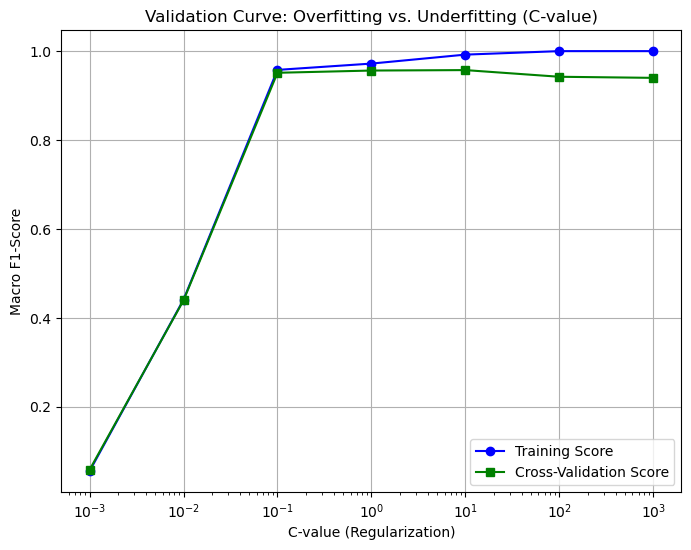

In [35]:
param_range = np.logspace(-3, 3, 7)
train_scores_vc, test_scores_vc = validation_curve(
    SVC(kernel='rbf', class_weight='balanced', random_state=42), 
    new_dataset, y_train, param_name="C", param_range=param_range,
    cv=5, scoring="f1_macro", n_jobs=-1
)

train_mean_vc = np.mean(train_scores_vc, axis=1)
test_mean_vc = np.mean(test_scores_vc, axis=1)

plt.figure(figsize=(8, 6))
plt.semilogx(param_range, train_mean_vc, label='Training Score', color='blue', marker='o')
plt.semilogx(param_range, test_mean_vc, label='Cross-Validation Score', color='green', marker='s')
plt.title('Validation Curve: Overfitting vs. Underfitting (C-value)')
plt.xlabel('C-value (Regularization)')
plt.ylabel('Macro F1-Score')
plt.legend(loc='best')
plt.grid()
plt.show()

The plot above shows the effect of the gamma value on the model F1 score, When the gamma is very low both the training and validation scores are terrible. The decision boundary is too simple to capture the complex biological differences between the subtypes. And if the number for gamma is too high, overfitting occurs. the training score pushes up to nearly 1.0, but the green validation score drops down to ~0.82. The model has become too complex. The same statment can be said about the C-value, if the c_value is low, for example a value of ($C=10^{-3}$ to $10^{-2}$), the SVM becomes very lenient with the soft margin, and the model severely underfits (high bias) the data (both training and cross-validation F1-scores below 0.50). But as soon as it gets to $C=10^{-1}$, the model finds the best decision boundary, and both training and cross-validation F1-scores peak and converge (and stay) at 0.95, where the model has the optimal complexity for learning generalizable metagene signatures.This justifies why a Grid Search is needed, in order to try different parameters to find the best accuracy and the best parameter to generalise well.

## 2. Model Development

he baseline SVM showed severe bias against minority classes (Class 1) and struggled with overlapping biological boundaries (low decision margins). Furthermore, the validation curves proved the model is highly sensitive to C and gamma parameters. To address these specific issues, we will develop an optimized pipeline. First, Over-sampling will be implemented strictly on the training set to resolve class imbalance. Second, 5-Fold Stratified GridSearchCV is used to systematically tune the RBF kernel (C and gamma) to navigate the complex epigenetic continuum.

### Note: This section include also Justification and Stratigies to address model issues.

### 2.1 Oversampling

The frist that can be thought of in terms of improving the performance of the model is to look at the imbalance in the dataset, this was one major issue for the model. The model couldn't distinguish between subtypes like 3 and 4 because it didn't have enough smaples that belong to those subtypes to train on, and subtype 1 was misclassified once because it is the minorty class in the dataset. Oversampling [3] can solve this issue, random oversmapling samples more data points from the minorty class till it reaches a balanced state. There is another type called imbalance or undersmapling it won't be used since it deletes data from the majority classes, and this might result in a smaller training dataset, and a small dataset can result in a worse performance when testing.

After applying the oversmapling process it can be observed that the new dataset is 2056 samples which is double the original training set, this is done only on the training set. When plotting the distribution of the new datasetall subtypes have a equal number of samples.

In [36]:
# init the oversampler 
ros = RandomOverSampler(random_state=42)
# Get the new dataset with oversampling 
X_train_resampled, y_train_resampled = ros.fit_resample(new_dataset, y_train)
# print the number of smaples before and after sampling
print(f"Total training samples before: {len(y_train)}")
print(f"Total training samples after: {len(y_train_resampled)}")

Total training samples before: 1016
Total training samples after: 2056


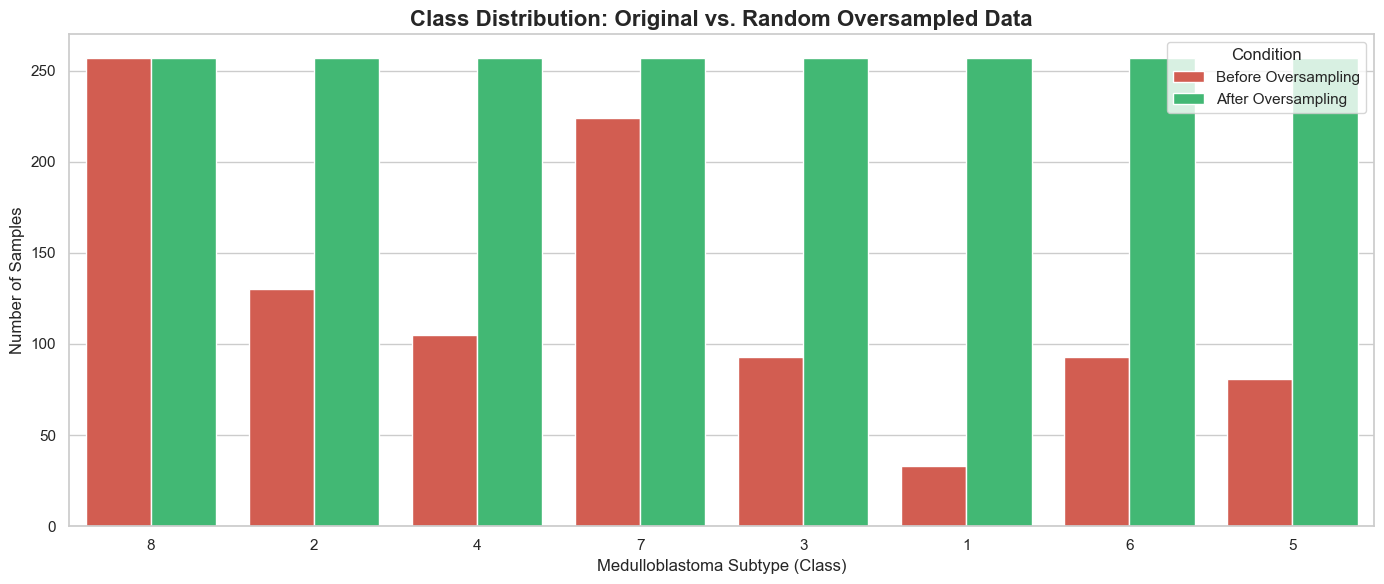

In [37]:
df_before = pd.DataFrame({'Subtype': y_train, 'Dataset': 'Before Oversampling'})
df_after = pd.DataFrame({'Subtype': y_train_resampled, 'Dataset': 'After Oversampling'})


df_combined = pd.concat([df_before, df_after])
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.countplot(
    data=df_combined, 
    x='Subtype', 
    hue='Dataset', 
    palette=['#e74c3c', '#2ecc71'] 
)


plt.title('Class Distribution: Original vs. Random Oversampled Data', fontsize=16, fontweight='bold')
plt.xlabel('Medulloblastoma Subtype (Class)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.legend(title='Condition')
plt.tight_layout()
plt.show()

### 2.1 Hyperparameter Tuning and Grid Search

For Hyperparameter tuning and optimizing the model, a pipline was implemented to do a grid search on a parameter grid with different values for each parameter the pipline would first oversampled and then applyed standardScaler, which is important to improve SVC performance, then use the ImbPipline, because it ensures that only oversampling happens on the training set to prevent data leakage.

Different Parameters were used for the grid search:

- `C-value`: the regularization parameter which is used to penalize the model when it misclassifies. a small values allows for missclassification and is better for generalization, while a large value penelizes the model and hence the model might overfit.
- `Gamma`: Controls how far the influence of a single sample extends. small values results in underfitting, while alarge value results in overfitting.
- `kernal`: tow options. Linear which is good for smaller datasets and high dimensional data. The second option is `rdf` which is good for complex non-linear data.
- `class_weight`: The value `None` will result in the model treating all classes equally, while `balanced` will result in adjusting weights and focusing on minority classes.

The grid search will run using a `5`-cross validation, and focus on the macro-F1 score as it's matrics for evaluating the best model, instead of global accuracy.

> **Consolidation note:** Oversampling is inside the original CV pipeline, but NMF was already fitted on the complete training split before CV. The recorded CV means therefore do not include fully fold-specific factorization. The later package moves NMF inside CV.

In [38]:
def optimize_svm_pipeline(X_train_data, y_train_data):
    print(f"Starting Pipeline Optimization on dataset shape: {X_train_data.shape}...")

    # pipeline steps 
    # oversample 
    # standarize
    # set the classification model
    pipeline_steps = [
        ('ros', RandomOverSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('svm', SVC(probability=True, random_state=42)) 
    ]
    optimized_pipeline = ImbPipeline(steps=pipeline_steps)

    # Parameters grid for the grid search
    param_grid = {
        'svm__C': [0.1, 1, 10, 100, 1000],          
        'svm__gamma': ['scale', 0.001, 0.01, 0.1, 1], 
        'svm__kernel': ['linear', 'rbf'],
        'svm__class_weight': [None, 'balanced']
    }

    # Metrics 
    scoring_metrics = {
        'Accuracy': 'accuracy',
        'Macro_F1': 'f1_macro',
        'Micro_F1': 'f1_micro'
    }

    # Grid search with cross validation of 5 
    grid_search = GridSearchCV(
        estimator=optimized_pipeline,
        param_grid=param_grid,
        cv=5,                  
        scoring=scoring_metrics,  
        refit='Macro_F1',         
        n_jobs=-1,             
        verbose=0            
    )

    # Fit the model
    grid_search.fit(X_train_data, y_train_data)
    
    # Print results
    best_index = grid_search.cv_results_['params'].index(grid_search.best_params_)
    best_macro = grid_search.cv_results_['mean_test_Macro_F1'][best_index]
    best_micro = grid_search.cv_results_['mean_test_Micro_F1'][best_index]
    best_acc = grid_search.cv_results_['mean_test_Accuracy'][best_index]

    print("Best Hyperparameters Found:")
    for param, value in grid_search.best_params_.items():
        print(f" - {param.replace('svm__', '')}: {value}")
        
    print("\n Best Model Performance")
    print(f"Macro F1-Score: {best_macro:.4f}")
    print(f"Micro F1-Score: {best_micro:.4f}")
    print(f"Accuracy:       {best_acc:.4f}\n")

    # Return the best model
    return grid_search.best_estimator_, grid_search

In [39]:
def parameter_heatmap(grid_search):
    cv_results = pd.DataFrame(grid_search.cv_results_)
    
    # get the best parameter for the kernal and thw weights and fix them 
    best_kernel = grid_search.best_params_['svm__kernel']
    best_class_weight = grid_search.best_params_['svm__class_weight']
    
    if best_class_weight is None:
        mask = (cv_results['param_svm__kernel'] == best_kernel) & (cv_results['param_svm__class_weight'].isnull())
    else:
        mask = (cv_results['param_svm__kernel'] == best_kernel) & (cv_results['param_svm__class_weight'] == best_class_weight)
    
    filtered_results = cv_results[mask]
    
    # Create a pivot table for the heatmap 
    heatmap_data = filtered_results.pivot(
        index='param_svm__C', 
        columns='param_svm__gamma', 
        values='mean_test_Macro_F1'
    )
    
    # Ensure the indices and columns are numeric/string for plotting
    heatmap_data.index = heatmap_data.index.astype(float)
    heatmap_data.columns = heatmap_data.columns.astype(str)
    
    # Plot the Seaborn Heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        heatmap_data, 
        annot=True,          
        fmt='.4f',           
        cmap='magma',        
        cbar_kws={'label': 'Mean Cross-Validation Macro F1-Score'}
    )
    
    # Formatting
    plt.title(f'Hyperparameter Performance Heatmap\n(Kernel: {best_kernel}, Class Weight: {best_class_weight})', 
              fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Gamma (Kernel Coefficient)', fontsize=12)
    plt.ylabel('C (Regularization Parameter)', fontsize=12)
    plt.gca().invert_yaxis() 
    
    plt.tight_layout()
    plt.show()

### Optimized Model using 10 Components for NMF

In [40]:
# run the grid searhc to find the best hyperparameters for the model
best_model_k10, grid_search = optimize_svm_pipeline(new_dataset, y_train)

Starting Pipeline Optimization on dataset shape: (1016, 10)...
Best Hyperparameters Found:
 - C: 1
 - class_weight: None
 - gamma: scale
 - kernel: rbf

 Best Model Performance
Macro F1-Score: 0.9609
Micro F1-Score: 0.9675
Accuracy:       0.9675



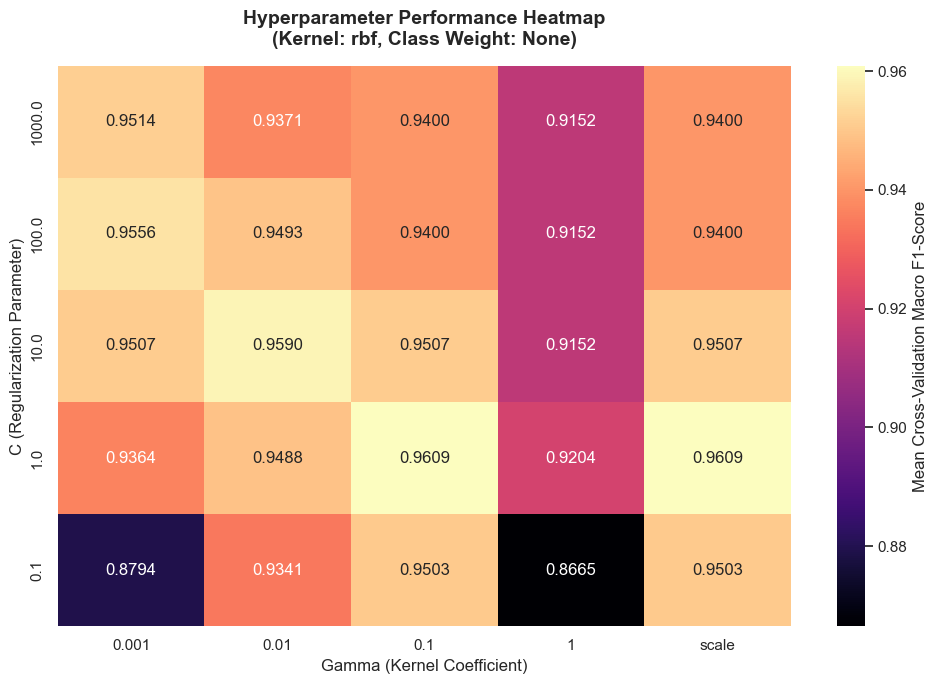

In [41]:
# print out the heatmap 
parameter_heatmap(grid_search)

The hyperparameter performance heatmap for the SVM (RBF kernel) displays the mean cross-validation Macro F1-scores for a 5x5 parameter grid, which determined the optimal configuration (C=1 and gamma=scale) at a Macro F1-score of 0.9609. The heatmap topography also shows that this optimal configuration falls within a stable region of high performance (the bright yellow band between C=1 to C=10), ruling out any arbitrary parameter spikes and clearly illustrating the model boundary limits (e.g., the lowest performance region (C=0.1, gamma=1, Macro F1=0.8665) is an example of extreme underfitting, where a very small kernel radius (high gamma) directly contradicted a high penalty tolerance (low C), while the baseline parameters chosen by the grid search avoid overfitting by keeping the decision boundary smooth and maximize its ability to generalize.

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       0.97      1.00      0.99        33
           3       0.85      0.96      0.90        23
           4       0.91      0.81      0.86        26
           5       1.00      1.00      1.00        20
           6       0.96      0.96      0.96        23
           7       0.97      0.98      0.97        57
           8       1.00      0.97      0.98        65

    accuracy                           0.96       255
   macro avg       0.96      0.96      0.96       255
weighted avg       0.96      0.96      0.96       255


Explicit F1-Scores:
Macro F1-Score: 0.9569
Micro F1-Score: 0.9608


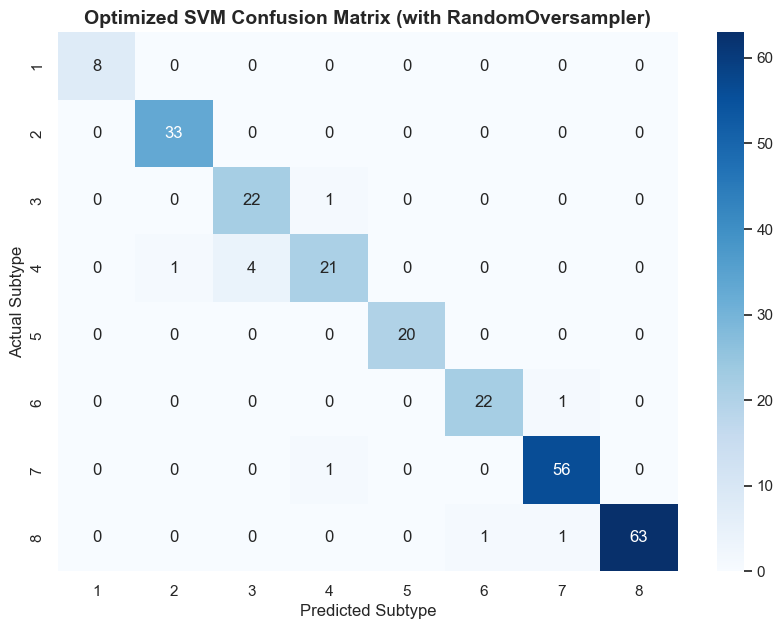

In [42]:
# test the model
y_test_pred_opt = best_model_k10.predict(new_test_dataset)
# get the scores for both the F1 scores
macro_f1 = f1_score(y_test, y_test_pred_opt, average='macro')
micro_f1 = f1_score(y_test, y_test_pred_opt, average='micro')

# print classifcation report and F1 scores and then confussion matrix
print(classification_report(y_test, y_test_pred_opt))
print(f"\nExplicit F1-Scores:")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Micro F1-Score: {micro_f1:.4f}")
cm_opt = confusion_matrix(y_test, y_test_pred_opt)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Optimized SVM Confusion Matrix (with RandomOversampler)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Subtype', fontsize=12)
plt.xlabel('Predicted Subtype', fontsize=12)
plt.show()

In [43]:
# get dataframe for the misclassification
full_results, misclassified, discordant = analyze_decision_margins(
    model=best_model_k10, 
    X_test=new_test_dataset, 
    y_test=y_test, 
    margin_threshold=0.20  
)
# print the discordant smaples.
display(discordant)

--- Margin Analysis Summary ---
Total Misclassified Samples: 10
Highly Discordant Misclassifications (Margin < 0.2): 3
Overall Model Log-Loss: 0.1184



,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3876618,8,7,7,0.470,8,0.280,0.190
GSM3877476,6,7,7,0.522,6,0.429,0.093
GSM3877732,4,2,2,0.432,4,0.430,0.002


In [44]:
misclassified

,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3876375,3,4,4,0.482,3,0.257,0.225
GSM3876396,8,6,6,0.754,8,0.218,0.537
GSM3876538,4,3,3,0.868,4,0.119,0.749
GSM3876618,8,7,7,0.470,8,0.280,0.190
GSM3876851,7,4,4,0.858,7,0.124,0.734
GSM3877008,4,3,3,0.788,4,0.202,0.587
GSM3877232,4,3,3,0.573,2,0.255,0.317
GSM3877288,4,3,3,0.995,7,0.002,0.993
GSM3877476,6,7,7,0.522,6,0.429,0.093


Although the Micro F1 score only improved slightly from 0.9569 to 0.9608, the most important improvment was the Macro F1-score, which increased from 0.9472 to 0.9569, and this shows that the optimized model did not just increase its accuracy by defaulting to majority classes. In particular, the RandomOverSampler was able to help the model focus on the minority Subtype 1 and raised its F1-score to 1.00, which means that the model had learned it.

After tuning the SVM hyperparameters and correcting for the minority class bias, 10 samples from the test set remained misclassified: GSM3876375, GSM3876396, GSM3876538, GSM3876618, GSM3876851, GSM3877008, GSM3877232, GSM3877288, GSM3877476, GSM3877732. looking into the prediction probabilities indicates that these errors can be caused by two reasons: 

- Low decision margins for samples and confusion between Subtype 3 and Subtype 4.
    
- Misclassifying with high confidence score with sample GSM3877288 (Actual 4) misclassified with 99.5% confidence. which it for 50% of the misclassifications.

This can be explained by going back to the dimensionality reduction stage: The SVM classifier is doing it's best, but the 10-component NMF metagene space does not have the biological resolution to distinguish the very complex differences between Medulloblastoma Groups 3 and 4. The number of components for the NMF will be increased to 15 to improve performance.

### Optimized Model using 15 Components for NMF

To improve the model performance, NMF components were increased to 15, to provide the model with more metagenes to work with. This might help the model distinuish between the subtypes.

In [45]:
X = train_set.values

# make a nmf with 15 components 
new_nmf_model = NMF(n_components=15, init='nndsvd', random_state=42,  max_iter=4000)
new_dataset_matrix = new_nmf_model.fit_transform(X)

# get new dataset with the 15 metagenes 
new_dataset_k15 = pd.DataFrame(
    new_dataset_matrix, 
    index=train_set.index, 
    columns=['Metagene_1', 'Metagene_2', 'Metagene_3', 'Metagene_4', 'Metagene_5', 'Metagene_6', 'Metagene_7',
            'Metagene_8', 'Metagene_9', 'Metagene_10', 'Metagene_11', 'Metagene_12', 'Metagene_13', 'Metagene_14', 'Metagene_15']
)
new_dataset_k15

,Metagene_1,Metagene_2,Metagene_3,Metagene_4,Metagene_5,Metagene_6,Metagene_7,Metagene_8,Metagene_9,Metagene_10,Metagene_11,Metagene_12,Metagene_13,Metagene_14,Metagene_15
Samples,,,,,,,,,,,,,,,
GSM3876338,0.291367,0.148405,0.092566,0.000000,0.000000,0.415535,0.169877,0.093422,0.078652,0.533716,0.000000,0.000000,0.000000,0.000000,1.449186
GSM3876339,0.000000,0.417376,0.000000,0.000000,0.000000,0.000000,0.000000,0.325255,0.468325,0.000000,0.000000,0.000000,2.005718,1.284687,0.000000
GSM3876340,0.261052,1.052907,0.013096,1.571647,0.213984,0.087343,0.018334,0.004939,0.012564,0.109097,0.000000,0.821333,0.401486,0.525094,0.041782
GSM3876342,0.488673,0.459139,0.041676,0.227881,0.227068,0.000000,0.086096,0.205403,0.000000,0.200792,0.000000,0.000000,2.020884,1.485401,0.037597
GSM3876343,0.375398,0.128005,0.202312,0.000000,0.094100,0.394034,0.039419,0.094539,0.000000,0.852766,0.000000,0.000000,0.000000,0.000000,1.298712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877739,0.231505,0.594988,0.000000,0.285251,0.000000,0.000000,0.000000,0.000000,0.090744,0.035945,0.000000,1.449578,1.841564,0.200949,0.000000
GSM3877740,0.331260,0.473463,0.008139,0.364687,0.175648,0.530734,0.215322,0.275594,0.000000,0.974285,0.733465,0.016984,0.322396,0.333139,0.230456
GSM3877741,0.335420,0.607572,0.019837,0.258213,0.633940,0.000000,0.003140,0.096777,0.000000,0.000000,0.108209,1.489087,0.423588,0.036120,0.008272


In [46]:
# get the best model and it's hyper parameters 
best_model_k15, grid_search_k15 = optimize_svm_pipeline(new_dataset_k15, y_train)

Starting Pipeline Optimization on dataset shape: (1016, 15)...
Best Hyperparameters Found:
 - C: 0.1
 - class_weight: None
 - gamma: scale
 - kernel: linear

 Best Model Performance
Macro F1-Score: 0.9682
Micro F1-Score: 0.9724
Accuracy:       0.9724



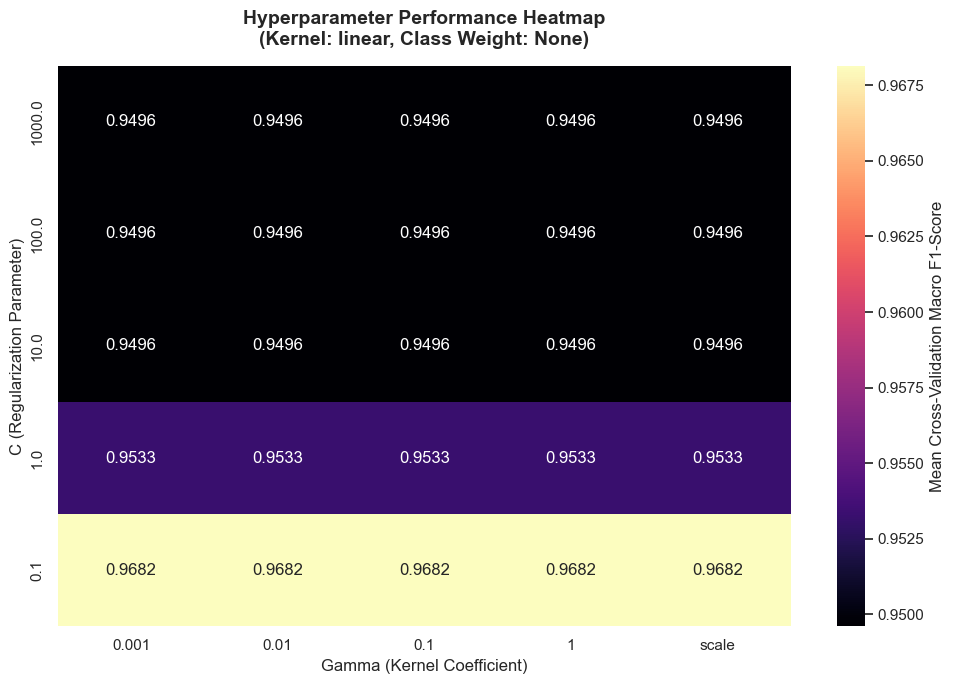

In [47]:
parameter_heatmap(grid_search_k15)

The first noticable difference between the two optmized models going from 10 to 15 components, is the fact that the model moved from a `rbf` kernel to a `linear` kernel. This is due changing NMF to 15 components, which means more added dimensionality. As dimensions increases, data naturally becomes easier to separate with straight lines. Moreover a linear SVM does not use the gamma parameter, because the model chose a linear boundary, changing gamma does nothing. That is why every single row in your heatmap is identical from left to right. The selection of a low regularization parameter (C=0.1) indicates the model prioritized a wider decision margin. This is a highly effective regularization value to prevent overfitting and to generalize well.

In [48]:
# transform the testing set using the 15 components nmf 
X_test = test_set.values.astype('float64')
test_dataset_matrix = new_nmf_model.transform(X_test)

# get the new reduced testing set using the 15 components 
new_test_dataset_k15 = pd.DataFrame(
    test_dataset_matrix, 
    index=test_set.index, 
    columns=['Metagene_1', 'Metagene_2', 'Metagene_3', 'Metagene_4', 'Metagene_5', 'Metagene_6', 'Metagene_7',
             'Metagene_8', 'Metagene_9', 'Metagene_10', 'Metagene_11', 'Metagene_12', 'Metagene_13', 'Metagene_14', 'Metagene_15']
)
new_test_dataset_k15

,Metagene_1,Metagene_2,Metagene_3,Metagene_4,Metagene_5,Metagene_6,Metagene_7,Metagene_8,Metagene_9,Metagene_10,Metagene_11,Metagene_12,Metagene_13,Metagene_14,Metagene_15
gsm,,,,,,,,,,,,,,,
GSM3876341,0.433873,0.367899,0.000000,0.000000,0.023057,0.204994,0.038963,0.346233,0.065348,0.016317,0.162713,0.000000,3.147586,0.728408,0.033059
GSM3876345,0.248225,0.017378,0.005979,0.000000,0.014761,0.042786,0.000000,0.107335,0.027809,0.456940,0.000000,0.000000,0.016981,0.000000,1.919890
GSM3876352,0.195052,0.121535,0.103035,0.025871,0.000000,0.109494,0.000000,0.000000,0.000000,0.829039,0.130545,0.069143,0.104934,0.000000,1.792396
GSM3876353,0.047622,0.000000,0.000000,0.241382,0.000000,0.000000,0.076135,0.205668,0.110580,0.000000,0.293301,0.000000,0.124793,2.689408,0.703952
GSM3876366,0.000000,1.121799,0.066007,1.483567,0.431520,0.000000,0.192114,0.298958,0.138994,0.000000,0.208881,0.616932,0.446590,0.111009,0.028340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877721,0.565362,0.888121,0.028769,1.415480,0.112456,0.137725,0.000000,0.159536,0.115252,0.124526,0.178479,0.849707,0.004497,0.212360,0.035195
GSM3877726,0.104818,0.181763,0.000000,0.000000,0.000000,0.000000,0.049958,0.075299,0.132214,0.715977,0.065872,0.061759,0.279899,0.133476,2.003574
GSM3877732,0.525353,0.802322,0.055079,0.757445,0.000000,0.038735,0.012606,0.000000,0.146951,0.231953,0.000000,0.526749,0.818420,1.013040,0.019330


              precision    recall  f1-score   support

           1       1.00      0.88      0.93         8
           2       0.94      1.00      0.97        33
           3       0.88      1.00      0.94        23
           4       0.96      0.85      0.90        26
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        23
           7       1.00      0.98      0.99        57
           8       1.00      1.00      1.00        65

    accuracy                           0.98       255
   macro avg       0.97      0.96      0.97       255
weighted avg       0.98      0.98      0.98       255


Explicit F1-Scores:
Macro F1-Score: 0.9665
Micro F1-Score: 0.9765


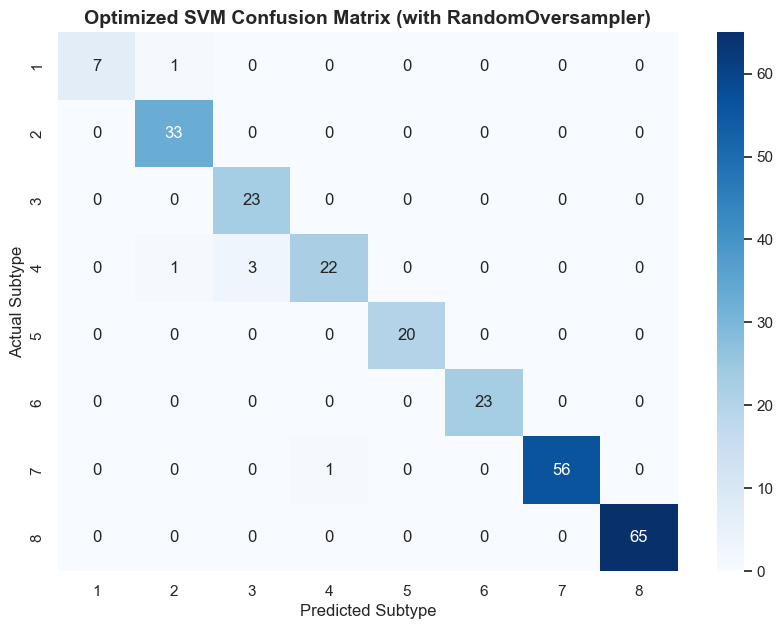

In [49]:
y_test_pred_opt = best_model_k15.predict(new_test_dataset_k15)
macro_f1 = f1_score(y_test, y_test_pred_opt, average='macro')
micro_f1 = f1_score(y_test, y_test_pred_opt, average='micro')

print(classification_report(y_test, y_test_pred_opt))
print(f"\nExplicit F1-Scores:")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Micro F1-Score: {micro_f1:.4f}")
cm_opt = confusion_matrix(y_test, y_test_pred_opt)

plt.figure(figsize=(10, 7)) 
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Optimized SVM Confusion Matrix (with RandomOversampler)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Subtype', fontsize=12)
plt.xlabel('Predicted Subtype', fontsize=12)
plt.show()

In [50]:
# get details for misclassification and discordent 
full_results, misclassified, discordant = analyze_decision_margins(
    model=best_model_k15, 
    X_test=new_test_dataset_k15, 
    y_test=y_test, 
    margin_threshold=0.20  
)

discordant

--- Margin Analysis Summary ---
Total Misclassified Samples: 6
Highly Discordant Misclassifications (Margin < 0.2): 2
Overall Model Log-Loss: 0.1088



,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3876607,1,2,2,0.336,1,0.238,0.098
GSM3877732,4,2,4,0.481,2,0.434,0.046


In [51]:
misclassified

,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3876538,4,3,3,0.610,4,0.341,0.270
GSM3876607,1,2,2,0.336,1,0.238,0.098
GSM3876851,7,4,4,0.668,7,0.296,0.372
GSM3877232,4,3,3,0.575,4,0.186,0.389
GSM3877288,4,3,3,0.999,4,0.001,0.998
GSM3877732,4,2,4,0.481,2,0.434,0.046


> **Consolidation note:** The move to 15 components followed inspection of test errors, so these results are retrospective and exploratory. The original 97.65% accuracy is preserved. Confident disagreement cannot prove clinical mislabeling; no reference labels are changed.

The transition from a 10-component to a 15-component NMF dataset yielded the highest-performing model in the pipeline, achieving an overall test accuracy of 98% and a Micro F1-Score of 0.9765. The Macro F1-Score reached an impressive 0.9665, showing strong performance on this test set, although errors remained for some subtypes.

The reason behind expanding to 15 components in the NMF was to disentangle the overlapping subtype 3 and subtype 4. The optimized 10-component model yielded 10 total misclassifications, 50% of which belonged to subtype 3/4 confusion. By using 15 components, the model successfully reduced the total test set misclassifications down to just 6 samples, improving the separation of these subtypes, although three Subtype 4 samples were still assigned to Subtype 3. Furthermore, Subtypes 5, 6, and 8 are now classified with perfect 1.00 F1-scores.

Sample GSM3876607 which belongs to subtype 1 was misclassified, but the decision margin shows it is exceptionally low at 0.098. The second highest score was the correct subtype. Similarly, GSM3877732 had a margin of just 0.046. These results might be caused by the fact that MB cancer subtypes have mixed molecular signatures.

Sample GSM3877288 which belongs to subtype 4 remains misclassified as Class 3 with a 99.9% confidence. Because this error persists with near-absolute confidence across both the 10-component (RBF kernel) and 15-component (Linear kernel) models, this sample is worth investigating further. Confidence alone does not establish that the original research label was wrong.

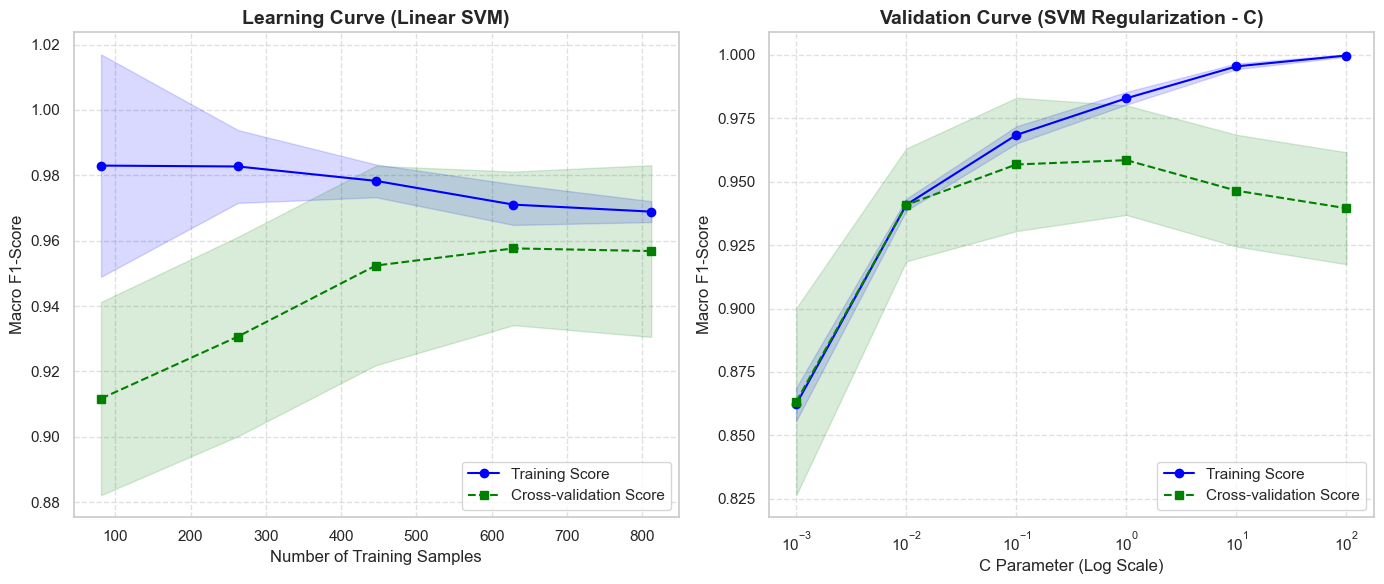

In [52]:
best_pipeline = ImbPipeline(steps=[
    ('ros', RandomOverSampler(random_state=42)),
    ('svm', SVC(kernel='linear', C=0.1, probability=True, random_state=42))
])

train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_pipeline,
    X=new_dataset_k15, 
    y=y_train,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_mean, color='blue', marker='o', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, color='green', marker='s', linestyle='--', label='Cross-validation Score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')
plt.title('Learning Curve (Linear SVM)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

train_scores_vc, test_scores_vc = validation_curve(
    estimator=best_pipeline,
    X=new_dataset_k15, 
    y=y_train,
    param_name="svm__C",
    param_range=param_range,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
train_mean_vc = np.mean(train_scores_vc, axis=1)
train_std_vc = np.std(train_scores_vc, axis=1)
test_mean_vc = np.mean(test_scores_vc, axis=1)
test_std_vc = np.std(test_scores_vc, axis=1)

plt.subplot(1, 2, 2)
plt.semilogx(param_range, train_mean_vc, label="Training Score", color="blue", marker='o')
plt.fill_between(param_range, train_mean_vc - train_std_vc, train_mean_vc + train_std_vc, alpha=0.15, color="blue")
plt.semilogx(param_range, test_mean_vc, label="Cross-validation Score", color="green", marker='s', linestyle='--')
plt.fill_between(param_range, test_mean_vc - test_std_vc, test_mean_vc + test_std_vc, alpha=0.15, color="green")
plt.title('Validation Curve (SVM Regularization - C)', fontsize=14, fontweight='bold')
plt.xlabel('C Parameter (Log Scale)', fontsize=12)
plt.ylabel('Macro F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

As shown in the Learning Curve, the 15-component model seems to be able to strike the right balance of low bias and low variance, as the training and cross-validation scores plateau at a high Macro F1-Score of ~0.97 as more training data are added, and the gap between the two curves is extremely narrow, indicating that the model is not memorizing the training set but generalizes well to unseen data.

The validation curve clearly shows how the model is sensitive to the regularization parameter C, where very small C values underfit with a very soft decision margin, and high C values overfit the model with the training score reaching 1.0 and validation scores dropping. The grid search found C = 0.1 to be the best parameter value that maximizes cross-validation performance at the point where variance starts to become a negative factor.

> **Consolidation note:** The validation scores below test the available paired processing representations of the reserved cohort. They do not prove absence of batch effects or validate a biological mechanism. Learning curves in the original record also use already fitted NMF features.

## Model Validation, and Generalization 

to test the generalization of the best model on a both platforms, the best model will predict the subtypes for the samples using the validation sets for both the hm450 and epic

### HM450 Platform

In [53]:
# transform the hm450 validation set using the 15 components nmf 
X_validation_hm450 = hm450_validation_set.values.astype('float64')
hm450_valid_dataset_matrix = new_nmf_model.transform(X_validation_hm450)

# get the new reduced testing set using the 15 components 
hm450_validation_reduced = pd.DataFrame(
    hm450_valid_dataset_matrix, 
    index=hm450_validation_set.index, 
    columns=['Metagene_1', 'Metagene_2', 'Metagene_3', 'Metagene_4', 'Metagene_5', 'Metagene_6', 'Metagene_7',
             'Metagene_8', 'Metagene_9', 'Metagene_10', 'Metagene_11', 'Metagene_12', 'Metagene_13', 'Metagene_14', 'Metagene_15']
)
hm450_validation_reduced

,Metagene_1,Metagene_2,Metagene_3,Metagene_4,Metagene_5,Metagene_6,Metagene_7,Metagene_8,Metagene_9,Metagene_10,Metagene_11,Metagene_12,Metagene_13,Metagene_14,Metagene_15
gsm,,,,,,,,,,,,,,,
GSM3877742,0.000000,0.467324,0.000000,0.990305,1.081712,0.200632,0.107735,0.348282,0.000000,0.159051,0.064594,1.014528,0.000000,0.126795,0.075140
GSM3877746,0.056154,0.347214,0.188911,0.010452,0.106569,0.000000,0.380145,0.258189,0.027394,0.832933,0.343022,0.034879,0.122215,0.779581,1.117487
GSM3877747,0.255756,0.236382,0.286142,0.090217,0.000000,0.000000,0.098076,0.111907,0.009625,1.263161,0.163923,0.000000,0.200929,0.000000,1.335434
GSM3877748,0.027575,0.387566,0.087839,0.074771,0.000000,0.371841,0.139324,0.193530,1.234124,0.000000,0.365834,0.126774,0.923027,0.014300,0.299152
GSM3877749,0.369599,0.477374,0.209954,0.088571,0.000000,0.550444,0.000000,0.288472,0.215001,0.750863,0.377292,0.151913,0.415152,0.022151,0.317571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.000000,0.009747,0.000000,0.000000,0.000000,0.000000,0.104789,0.129566,0.045708,0.968438,0.078323,0.154176,0.217886,0.058498,1.971187
GSM3877851,0.145504,0.942920,0.229339,0.000000,0.598661,0.000000,0.000000,0.000000,0.000000,0.033294,0.000000,0.208592,0.623302,0.586626,0.003817
GSM3877852,0.153324,0.110632,0.332211,0.000000,0.276454,0.284542,0.313794,0.315311,0.226550,1.102081,0.288358,0.141648,0.216672,0.001444,0.733951


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      0.93      0.96        14
           3       0.78      0.88      0.82         8
           4       0.78      0.78      0.78         9
           5       1.00      1.00      1.00         7
           6       0.67      1.00      0.80         4
           7       1.00      0.95      0.98        22
           8       1.00      0.96      0.98        25

    accuracy                           0.94        99
   macro avg       0.90      0.94      0.92        99
weighted avg       0.95      0.94      0.94        99


Explicit F1-Scores:
Macro F1-Score: 0.9151
Micro F1-Score: 0.9394


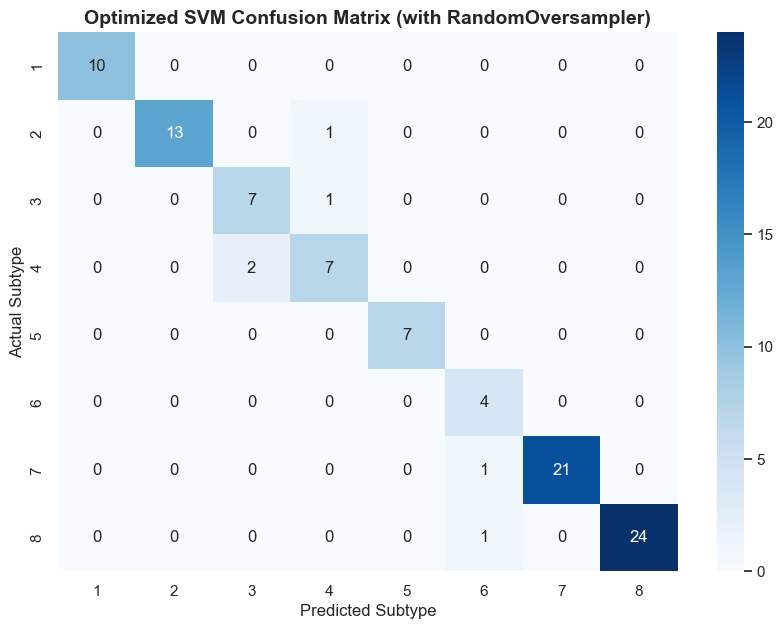

In [54]:
y_validation_hm450 = hm450_validation_set_info['subtype']
y_test_pred_opt = best_model_k15.predict(hm450_validation_reduced)
macro_f1 = f1_score(y_validation_hm450, y_test_pred_opt, average='macro')
micro_f1 = f1_score(y_validation_hm450, y_test_pred_opt, average='micro')

print(classification_report(y_validation_hm450, y_test_pred_opt))
print(f"\nExplicit F1-Scores:")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Micro F1-Score: {micro_f1:.4f}")
cm_opt = confusion_matrix(y_validation_hm450, y_test_pred_opt)

plt.figure(figsize=(10, 7)) 
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_validation_hm450), 
            yticklabels=np.unique(y_validation_hm450))
plt.title('Optimized SVM Confusion Matrix (with RandomOversampler)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Subtype', fontsize=12)
plt.xlabel('Predicted Subtype', fontsize=12)
plt.show()

In [55]:
# get details for misclassification and discordent 
full_results, misclassified, discordant = analyze_decision_margins(
    model=best_model_k15, 
    X_test=hm450_validation_reduced, 
    y_test=y_validation_hm450, 
    margin_threshold=0.20  
)

discordant

--- Margin Analysis Summary ---
Total Misclassified Samples: 6
Highly Discordant Misclassifications (Margin < 0.2): 3
Overall Model Log-Loss: 0.1598



,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3877754,4,3,3,0.562,4,0.419,0.144
GSM3877764,2,4,4,0.544,2,0.398,0.147
GSM3877845,3,4,4,0.494,3,0.492,0.001


In [56]:
misclassified

,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3877742,4,3,3,0.617,4,0.359,0.259
GSM3877754,4,3,3,0.562,4,0.419,0.144
GSM3877764,2,4,4,0.544,2,0.398,0.147
GSM3877768,7,6,6,0.597,7,0.341,0.256
GSM3877783,8,6,6,0.715,8,0.258,0.457
GSM3877845,3,4,4,0.494,3,0.492,0.001


Overall, the model had good generalization, with 94% accuracy and a Micro F1-Score of 0.9394 on the HM450 validation dataset, and a strong Macro F1-Score of 0.9151, which indicates that the model had strong predictive power across both minority and majority classes. Subtypes 1, 5, 7, and 8 all generalized exceptionally well, with F1-scores between 0.98 and 1.00, showing strong performance on this processing view. These scores alone do not establish that the components captured purely biological signatures or that batch effects were absent.

The 6 misclassified HM450 samples show recurring patterns that are useful for further investigation, without establishing their biological cause. The 50% of cross-platform errors (GSM3877742, GSM3877754, and GSM3877845) are entirely bidirectional confusion of Subtype 3 and Subtype 4, with sample GSM3877845 providing the perfect example of this ambiguity, as the SVM predicted Subtype 4 with 49.4% confidence and Subtype 3 with 49.2% confidence, with a decision margin of 0.001. Subtype 3/4 confusion was observed in both the original test set and this HM450-compatible processing view of the reserved cohort.

### Epic Platform 

In [57]:
# transform the epic validation set using the 15 components nmf 
X_validation_epic = epic_validation_set.values.astype('float64')
epic_valid_dataset_matrix = new_nmf_model.transform(X_validation_epic)

# get the new reduced testing set using the 15 components 
epic_validation_reduced = pd.DataFrame(
    epic_valid_dataset_matrix, 
    index=epic_validation_set.index, 
    columns=['Metagene_1', 'Metagene_2', 'Metagene_3', 'Metagene_4', 'Metagene_5', 'Metagene_6', 'Metagene_7',
             'Metagene_8', 'Metagene_9', 'Metagene_10', 'Metagene_11', 'Metagene_12', 'Metagene_13', 'Metagene_14', 'Metagene_15']
)
epic_validation_reduced

,Metagene_1,Metagene_2,Metagene_3,Metagene_4,Metagene_5,Metagene_6,Metagene_7,Metagene_8,Metagene_9,Metagene_10,Metagene_11,Metagene_12,Metagene_13,Metagene_14,Metagene_15
gsm,,,,,,,,,,,,,,,
GSM3877742,0.000000,0.623423,0.000000,1.009621,1.041083,0.158737,0.119076,0.465244,0.000000,0.200584,0.036716,1.024325,0.169124,0.134139,0.246637
GSM3877746,0.040289,0.389952,0.206937,0.000000,0.097333,0.000000,0.417641,0.324340,0.049496,0.942555,0.334266,0.048069,0.073337,0.792497,1.192995
GSM3877747,0.211437,0.270015,0.300082,0.061371,0.000000,0.000000,0.132275,0.176588,0.006819,1.432373,0.146346,0.000000,0.199964,0.000000,1.446974
GSM3877748,0.013141,0.445018,0.096294,0.039617,0.000000,0.400183,0.149087,0.251424,1.360769,0.000000,0.366343,0.117509,0.939725,0.000000,0.345627
GSM3877749,0.375735,0.514015,0.227488,0.046825,0.000000,0.597640,0.000000,0.349359,0.252413,0.847859,0.379850,0.169860,0.409253,0.000000,0.356835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM3877850,0.000000,0.032696,0.006552,0.000000,0.000000,0.000000,0.139088,0.175059,0.056396,1.138545,0.055691,0.187174,0.237448,0.039300,2.063622
GSM3877851,0.159915,1.067445,0.250343,0.000000,0.634134,0.000000,0.000000,0.068580,0.000000,0.000000,0.000000,0.218751,0.684211,0.571002,0.093827
GSM3877852,0.134778,0.122424,0.359970,0.000000,0.274264,0.295974,0.344930,0.362721,0.253633,1.211958,0.276124,0.128468,0.145015,0.000000,0.795912


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      0.93      0.96        14
           3       0.86      0.86      0.86         7
           4       0.70      0.88      0.78         8
           5       1.00      1.00      1.00         7
           6       0.57      1.00      0.73         4
           7       1.00      0.91      0.95        22
           8       1.00      0.92      0.96        25

    accuracy                           0.93        97
   macro avg       0.89      0.94      0.90        97
weighted avg       0.95      0.93      0.93        97


Explicit F1-Scores:
Macro F1-Score: 0.9045
Micro F1-Score: 0.9278


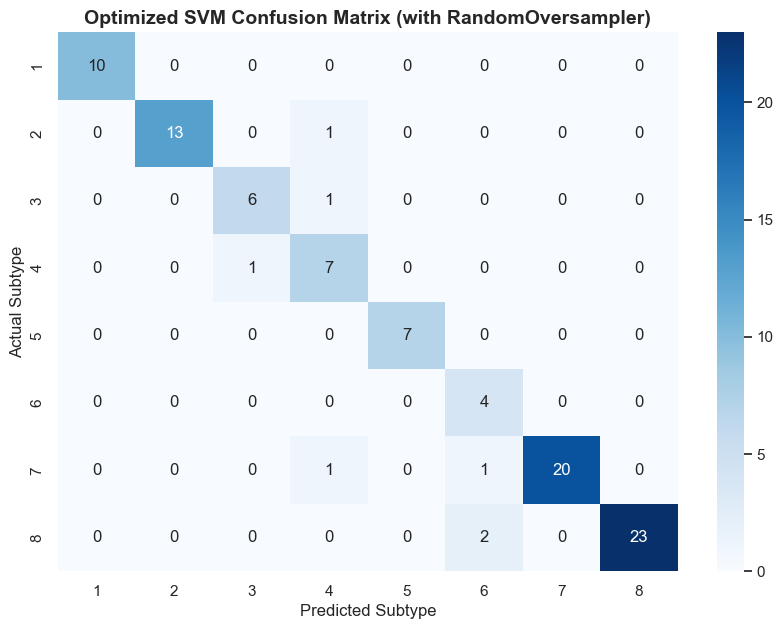

In [58]:
y_validation_epic = epic_validation_set_info['subtype']
y_test_pred_opt = best_model_k15.predict(epic_validation_reduced)
macro_f1 = f1_score(y_validation_epic, y_test_pred_opt, average='macro')
micro_f1 = f1_score(y_validation_epic, y_test_pred_opt, average='micro')

print(classification_report(y_validation_epic, y_test_pred_opt))
print(f"\nExplicit F1-Scores:")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Micro F1-Score: {micro_f1:.4f}")
cm_opt = confusion_matrix(y_validation_epic, y_test_pred_opt)

plt.figure(figsize=(10, 7)) 
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_validation_epic), 
            yticklabels=np.unique(y_validation_epic))
plt.title('Optimized SVM Confusion Matrix (with RandomOversampler)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Subtype', fontsize=12)
plt.xlabel('Predicted Subtype', fontsize=12)
plt.show()

In [59]:
# get details for misclassification and discordent 
full_results, misclassified, discordant = analyze_decision_margins(
    model=best_model_k15, 
    X_test=epic_validation_reduced, 
    y_test=y_validation_epic, 
    margin_threshold=0.20  
)

discordant

--- Margin Analysis Summary ---
Total Misclassified Samples: 7
Highly Discordant Misclassifications (Margin < 0.2): 3
Overall Model Log-Loss: 0.1720



,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3877746,8,6,6,0.532,8,0.380,0.152
GSM3877764,2,4,4,0.549,2,0.392,0.157
GSM3877854,7,4,7,0.313,6,0.299,0.014


In [60]:
misclassified

,Actual_Class,Hard_Prediction,Prob_Top1_Class,Confidence_Top1,Prob_RunnerUp_Class,Confidence_Top2,Decision_Margin
gsm,,,,,,,
GSM3877742,4,3,3,0.599,4,0.380,0.219
GSM3877746,8,6,6,0.532,8,0.380,0.152
GSM3877764,2,4,4,0.549,2,0.392,0.157
GSM3877768,7,6,6,0.650,7,0.306,0.344
GSM3877783,8,6,6,0.792,8,0.194,0.599
GSM3877845,3,4,4,0.601,3,0.388,0.213
GSM3877854,7,4,7,0.313,6,0.299,0.014


Validation of the 15-component model on the Illumina EPIC methylation array resulted in a very high accuracy of 93% and a Macro F1-Score of 0.9045, with strong classification results for Subtypes 1, 5, 7, and 8. The training, test and both validation inputs all used the same 11,234 matched probes. These results do not establish that NMF captured purely biological signatures or exclude array-specific technical effects. The same issue of subtype 3/4 is observed with the epic validation set, showing that confusion between those subtypes remained.

There was a difference in the EPIC results for Subtype 6, which had perfect Recall (1.00), but Precision (0.57) was driven by three samples (GSM3877746, GSM3877768, and GSM3877783, actual classes 7 and 8) incorrectly assigned to Class 6, indicating that the baseline signature of Subtype 6 may overlap with Subtypes 7 and 8 in terms of metagene features. Sample GSM3877854 presents has the actual subtype 7, and the SVM's hard prediction assigns to subtype 4. However, the probability distribution assigned the highest confidence (31.3%) to subtype 7, with subtype 6 being the second highest probability 29.9%, and a low decision margin of 0.014.

## Challenges and Limitations

The first dataset had an imbalanced class distribution, with a large minority class (Subtype 1) versus the majority class (Subtype 8). They addressed this by using RandomOverSampler (from imblearn pipeline) to generate minority samples in the training folds only during cross-validation to prevent data leakage and force the model to learn rare biological signatures. Running a 5-fold cross-validated GridSearchCV over a complex DNA methylation dataset was computationally expensive; they had to carefully balance and finalize the dimensionality reduction step (NMF) before grid searching to keep the optimization computationally viable without losing critical biological variance.

One of the limitations of this model is the biological nature of Medulloblastoma. Group 3 and Group 4 tumors are clinically known to be highly mixed [4]. Expanding the feature space to 15 NMF components and optimizing the SVM model did not resolve this issue, as a few samples such as GSM3877288 remained misclassified, indicating that 100% accuracy on this dataset may not be biologically attainable without overfitting.

Another limitation encountered during external validation is cross-platform feature variance and algorithmic probability scaling. While testing the model on independent Illumina HM450 and EPIC arrays, minor platform-specific bottlenecks were observed, and extreme edge-cases (e.g., EPIC sample GSM3877854) revealed a known mathematical limitation of Support Vector Machines. Platt scaling,  even if a tumor is on the boundary between two classes (with a very small margin such as 0.014), the mathematical rule for choosing a class can disagree with the percentage confidence score, and this points to a fundamental limitation: machine learning algorithms have clear mathematical boundaries, but real cancer biology can be messy and not easily fit into clear-cut boxes.

## Refrences

[1] Implementation and Evaluation of Support Vector Machine-Based Models for Cancer Detection Using Multi-Omic Data: A Systematic Review
Zhina Mohamadi, Erfan Abtahi, Zahra sadat Shayegh, Mehrafrin Ataei Kachouei, Amin Fakhar, Mohammad Mahdi Shirani, Mohammadhosein Malekian, Amir Zinatshoar, Mahdi Biglari, Fatemeh Rezaei, Armin Zarinkhat, Rozhina Mohammadi
bioRxiv 2025.07.10.664049; doi: https://doi.org/10.1101/2025.07.10.664049

[2] Hein, K. H., Woo, W. L., & Rafiee, G. (2025). Integrative Machine Learning Framework for Enhanced Subgroup Classification in Medulloblastoma. Healthcare, 13(10), 1114. https://doi.org/10.3390/healthcare13101114

[3] J. Brownlee, "Random oversampling and undersampling for imbalanced classification," Machine Learning Mastery, 2020. [Online]. Available: https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/

[4] Williamson, D., Schwalbe, E. C., Hicks, D., Aldinger, K. A., Lindsey, J. C., Crosier, S., Richardson, S., Goddard, J., Hill, R. M., Castle, J., Grabovska, Y., Hacking, J., Pizer, B., Wharton, S. B., Jacques, T. S., Joshi, A., Bailey, S., & Clifford, S. C. (2022). Medulloblastoma group 3 and 4 tumors comprise a clinically and biologically significant expression continuum reflecting human cerebellar development. Cell reports, 40(5), 111162. https://doi.org/10.1016/j.celrep.2022.111162

## AI Tools

Gemini was used for helping with the plotting for the figures and starturing the results in a dataframe and to fix grammer and vocab mistakes.